# Notebook 2 of 3: Mock project, part 1 - build the candidate edges, the forecasters and the baseline audit

A subscription betting startup wants to sell *provable* edges found among dozens of candidate signals (referee trends, rest and travel, recent form) and to combine them into one forecaster. This notebook is the first half of that engagement, written as a finished project write-up: the **brief with acceptance criteria**, the **data contract**, a **simulator standing in for the real data feeds**, a **library of 40 candidate signals** with a hidden truth table, the **frozen forecasters**, the client's current **naive pipeline** (screen, stack, look at ROI) and an **audit of that pipeline against the known truth**. The audit is a Monte Carlo over 200 independent simulated worlds with honest intervals. Notebook 3 reuses the exported cells of this notebook and applies three research papers (anytime-valid forecaster comparison, online false-discovery-rate control with e-values, calibeating) to the same pipeline.

**Framing.** This is a simulation study on synthetic data. It is not betting advice, and every result describes the simulator, not real markets. Only the conversion of odds to probabilities and the Brier-score convention are taken from a paper; everything else here (the simulator, the signals, the naive pipeline, all money figures) is *derived here* and carries no claim about real sportsbooks.

In [1]:
%matplotlib inline
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")   # single-thread BLAS is fastest for the small matrices used here
os.environ.setdefault("OMP_NUM_THREADS", "1")

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_START = time.time()
SEED_CONTRACT = 20240901      # world used for the data-contract checks (default configuration)
SEED_SHOWCASE = 20240902      # fixed showcase world (12 historical + 3 live seasons); chosen before looking at any result
AUDIT_SEEDS = np.arange(1000, 1200)    # 200 independent worlds, one seed each
DATA_DIR = Path("..") / "data"
DATA_DIR.mkdir(exist_ok=True)

# One palette for the whole notebook, reused in every figure.
PALETTE = {
    "real": "#2a9d8f", "subvig": "#e9c46a", "decay": "#f4a261", "proxy_real": "#457b9d",
    "proxy_null": "#a8b5c2", "leaky": "#e63946", "null": "#8d99ae",
    "market": "#222222", "stack": "#6a4c93", "in_sample": "#e63946", "forward": "#2a9d8f",
    "threshold": "#999999",
}
CLASS_ORDER = ["real", "subvig", "decay", "proxy_real", "proxy_null", "leaky", "null"]
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

# ---- helpers used only in this notebook (not exported) ----
CHECKS = []
def check(what, value, threshold, ok):
    """Print one numbered SELF-CHECK line. MET is printed only if the check passed its own threshold."""
    CHECKS.append(bool(ok))
    print(f"SELF-CHECK {len(CHECKS)}: {what} -> {value} (threshold {threshold}) -> {'MET' if ok else 'NOT MET'}")
    return bool(ok)

def wilson(k, n, z=1.959964):
    """Wilson score interval for a binomial proportion k/n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (mid - half, mid + half)

def boot_ci(x, stat=np.nanmean, B=4000, seed=0, level=0.95):
    """Bootstrap-over-worlds percentile interval for a statistic of a per-world array."""
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), (B, len(x)))
    draws = np.array([stat(x[i]) for i in idx])
    lo, hi = np.quantile(draws, [(1 - level) / 2, 1 - (1 - level) / 2])
    return float(stat(x)), float(lo), float(hi)

## 1. Project brief

**Client.** A subscription betting startup that sells "edges" to members. **Problem.** The analytics team has 40 candidate signals and a folder of backtests that look promising. Members pay for edges that are *provable*, and the founders cannot tell which backtest wins are real, which are luck, and which are bugs.

| # | Deliverable | What "done" means |
|---|---|---|
| D1 | Registry of candidate edges | every signal gets a verdict the client can defend to a member (real / not real / cannot tell), with the evidence behind it |
| D2 | One combined forecaster | a single home-win probability per game that is not worse than the market |
| D3 | Honest money view | flat-stake return at the *margined* quoted odds, in-sample versus forward, with the overround visible |
| D4 | Edge-decay monitor | an alarm when a published edge stops working |

**Acceptance criteria** (the client's targets; the numeric tolerances are *derived here*, not taken from any paper). Averages are over simulated worlds in which the truth is known.

| AC | Criterion | Target |
|---|---|---|
| AC1 | False-discovery proportion (FDP) among published signals | mean over worlds $\le 10\%$ |
| AC2 | No signal is published whose guarantee assumption (forecasts predictable from pre-game information) is violated | violating signal published in at most 1% of worlds |
| AC3 | The combined forecast is not worse than the de-margined market, by a valid interval | lower end of a valid 95% interval for its mean Brier differential is at least $-0.0005$ (higher-is-better convention) |
| AC4 | An edge that decays is flagged | within 3,690 games (three seasons) of the decay onset, with at most 5% false alarms per world |

**Scope of this notebook.** Part 1 builds the inputs (D1 candidates, D2 candidate forecasters, the data) and **scores the client's naive baseline against AC1 and AC2**. Part 2 (Notebook 3) applies the papers, builds the real D1-D4 and scores all four criteria against this baseline.

## 2. Data contract

The client's data platform delivers one row per game, in time order. The contract below is what every downstream step may rely on. The *information rule* is the important line: a feature attached to game $g$ may use only information that exists **before tip-off** of game $g$.

| Field | Type | Meaning |
|---|---|---|
| `y` | int8 | 1 if the home team won (binary outcome; draws do not exist in this sport) |
| `season` | int | 1-based season index (12 seasons of 1,230 games) |
| `odds_home`, `odds_away` | float | quoted **decimal** odds at close, margin included, rounded to 0.01 |
| `m_devig` | float | the analyst's de-margined home probability (implied probabilities $1/\text{odds}$ rescaled to sum to one) |
| `Z` | float32, $G \times 40$ | 40 candidate signals, each standardised to mean 0 and standard deviation 1 |
| `eval_mask` | bool | games of seasons 4-12 (the evaluation window, about 11,070 games) |

**Odds to probability, and the score.** For the odds conversion the pipeline follows the one used for Vegas closing odds in Choe and Ramdas (*Comparing Sequential Forecasters*, Sec. 5.2 and Appendix I.2): convert each quoted price to an implied probability, then rescale the pair to sum to one, $p_A = \tilde p_A/(\tilde p_A+\tilde p_B)$. The paper's data are American odds; here the odds are decimal, so the implied probability is simply $1/\text{odds}$. Forecasts are scored with the Brier score in the paper's convention $S(p,y)=1-(p-y)^2$, so **higher is better** and a positive score differential $S(p,y)-S(q,y)$ means $p$ beats $q$. For scale, the paper's MLB experiment uses ten seasons and 25,165 games (Sec. 5.2); the simulated 14,760 games are the same order of size.

**Hidden in the simulator only** (never in the contract): the true win probability `r_true`, the fair price `m_fair`, and the truth table of which signal is what. The audit below is possible only because the simulator knows them.

## 3. The simulator (derived here)

Real feeds are not available, so a simulator stands in for them. **Results below describe this simulator, not real markets.** It is built so that a careless backtest can go wrong in the ways real ones do.

* **Schedule and teams.** 30 teams, 165 game days per season, about 7.5 games a day, home side drawn at random. Team strength is a slowly drifting latent process; it gives the *fair price* $m^{\text{fair}}$ (home advantage included).
* **The market.** Quoted decimal odds carry a **proportional overround of 4.5%** (implied probabilities sum to 1.045) plus a little pricing noise, rounded to 0.01. The analyst de-margins them with the paper's conversion.
* **Truth.** $\operatorname{logit} r = a\,\operatorname{logit}(m^{\text{fair}}) + \sum_s \theta_s(t)\,z_{s,t} + \gamma f_A$ with $a = 1.06 > 1$: the market therefore **overprices longshots** (a planted price-band mispricing, *derived here*, deliberately not a signal). The outcome is $y \sim \text{Bernoulli}(r)$.
* **Forty candidate signals**, fixed layout, random sign per world: 12 *referee-crew* tendencies, 12 *rest/travel* features, 16 *form-trend* readings. Each is a function of information available before tip-off, with one deliberate exception (below).

| Class | Count | Hidden truth |
|---|---|---|
| `real` | 4 | genuine edges, 2.0 to 3.5 percentage points of win probability per standard deviation of the feature |
| `subvig` | 1 | a real edge (1.8 points per SD) that is **smaller than the overround**: Brier-detectable, not a money maker when followed at the margined odds |
| `decay` | 1 | a real edge (3.0 points) in seasons 1-4 that switches off afterwards |
| `proxy_real`, `proxy_null` | 3 + 3 | noisy readings of two latent form factors: one factor has a real effect (3.0 points), the other none, so the six signals form two correlated clusters |
| `leaky` | 1 | **look-ahead bug**: its historical feature contains part of tonight's outcome $y$. It has *no* true effect and looks brilliant in a backtest |
| `null` | 27 | no effect |

**Device.** Within each family the features are decorrelated (symmetric orthogonalisation) and freed of any linear link to the fair price, so a null feature is exactly null in the sample rather than a shadow of a real one. Real schedule features are collinear; this is a simulator convenience that keeps the truth table unambiguous.

**Design targets** (checked as SELF-CHECKs after the audit, tuned until they held): (i) the naive per-signal screen at $p<0.05$ yields about 1-3 false positives among the roughly 30 no-effect signals and finds some but not all real edges; (ii) the leaky signal is selected; (iii) the sub-vig signal has a positive expected Brier gain but a negative expected flat-stake ROI when followed at the margined odds; (iv) the decaying signal has a positive gap in the first evaluation season and none afterwards.

In [2]:
# EXPORT: edgelab_config
# Configuration of the simulated betting world (derived here; no real data).
CFG = dict(
    seasons=12,              # historical seasons (train + evaluation)
    games_per_season=1230,   # 30 teams x 82 games / 2
    n_teams=30,
    n_signals=40,            # 12 referee + 12 rest/travel + 16 form signals
    overround=0.045,         # proportional bookmaker margin on the implied probabilities
    train_seasons=3,         # forecasters are fitted on seasons 1..train_seasons, then frozen
    forward_seasons=0,       # extra "live" seasons after the historical window (audit only)
    days_per_season=165,
    offseason_days=60,
    n_referees=30,
    home_adv=0.12,           # logit home advantage in the fair price
    strength_sd=0.40,        # stationary sd of a team's logit strength
    strength_rho=0.998,      # daily persistence of team strength (slow drift)
    price_noise_sd=0.03,     # logit noise in the market's quoted price
    a_longshot=1.06,         # logit r = a * logit(m_fair) + ..., a > 1: market overprices longshots
    form_rho=0.92,           # daily persistence of latent form processes
    proxy_noise=0.70,        # reading noise of a proxy relative to its latent factor
    leak_strength=0.08,      # weight of the outcome inside the leaky feature (look-ahead bug)
    n_real_pp=(3.0, 2.5, 3.5, 2.0),   # real edges: win-probability points per SD of the feature
    subvig_pp=1.8,           # sub-vig edge (points per SD)
    decay_pp=3.0,            # decaying edge, active in seasons 1..decay_until
    decay_until=4,
    proxy_real_pp=3.0,       # effect of the real latent factor (points per SD of the factor)
)

In [3]:
# EXPORT: edgelab_devig
import numpy as np

def devig(odds_home, odds_away):
    """De-margin decimal odds: implied probabilities 1/odds, rescaled to sum to one
    (the conversion used for the Vegas odds in Choe & Ramdas, Sec. 5.2 / App. I.2)."""
    ih = 1.0 / np.asarray(odds_home, dtype=float)
    ia = 1.0 / np.asarray(odds_away, dtype=float)
    return ih / (ih + ia)

In [4]:
# EXPORT: edgelab_scores
import numpy as np

def brier(p, y):
    """Brier score in the higher-is-better convention S(p, y) = 1 - (p - y)^2."""
    return 1.0 - (np.asarray(p, dtype=float) - np.asarray(y, dtype=float)) ** 2

def score_diff(p, q, y):
    """Per-game score differential S(p,y) - S(q,y); positive means p beats q."""
    return brier(p, y) - brier(q, y)

In [5]:
# EXPORT: edgelab_sim
import numpy as np
import pandas as pd
from scipy.signal import lfilter

try:
    CFG
except NameError:   # standalone use of this cell
    CFG = dict(seasons=12, games_per_season=1230, n_teams=30, n_signals=40, overround=0.045,
               train_seasons=3, forward_seasons=0, days_per_season=165, offseason_days=60,
               n_referees=30, home_adv=0.12, strength_sd=0.40, strength_rho=0.998,
               price_noise_sd=0.03, a_longshot=1.06, form_rho=0.92, proxy_noise=0.70,
               leak_strength=0.08, n_real_pp=(3.0, 2.5, 3.5, 2.0), subvig_pp=1.8,
               decay_pp=3.0, decay_until=4, proxy_real_pp=3.0)

_PP_TO_LOGIT = 1.0 / 0.245     # 1 percentage point of win probability ~ 1/(100 * r(1-r)) logits at r ~ 0.5

def _signal_layout():
    """Fixed layout of the 40 candidate signals: names, families and hidden classes."""
    names = ([f"ref_{i:02d}" for i in range(1, 13)] + [f"rest_{i:02d}" for i in range(1, 13)]
             + [f"form_{i:02d}" for i in range(1, 17)])
    family = ["referee"] * 12 + ["rest_travel"] * 12 + ["form"] * 16
    cls = ["null"] * 40
    idx = {n: i for i, n in enumerate(names)}
    for n in ("ref_04", "rest_03", "form_02", "form_07"):
        cls[idx[n]] = "real"
    cls[idx["rest_10"]] = "subvig"
    cls[idx["form_05"]] = "decay"
    for n in ("form_10", "form_11", "form_12"):
        cls[idx[n]] = "proxy_real"
    for n in ("form_13", "form_14", "form_15"):
        cls[idx[n]] = "proxy_null"
    cls[idx["form_16"]] = "leaky"
    return names, family, cls, idx

def _std(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean(axis=0)) / x.std(axis=0)

def _decorrelate(A, ref):
    """Standardise the columns of A, remove their linear dependence on the fair price `ref`, then apply a
    symmetric (Loewdin) orthogonalisation so that the columns are exactly uncorrelated in sample.
    A device of the simulator: a null feature must be null, not a shadow of a real one."""
    A = _std(A)
    r = (ref - ref.mean()) / ref.std()
    A = A - r[:, None] * (A * r[:, None]).mean(axis=0)
    C = (A.T @ A) / A.shape[0]
    w, V = np.linalg.eigh(C)
    return A @ (V / np.sqrt(np.maximum(w, 1e-8))) @ V.T

def simulate_world(seed, cfg=CFG):
    """Simulate one betting world (derived here). Returns the dict W described in the data contract."""
    rng = np.random.default_rng(seed)
    T, D, OFF = cfg["n_teams"], cfg["days_per_season"], cfg["offseason_days"]
    S_hist, S = cfg["seasons"], cfg["seasons"] + cfg.get("forward_seasons", 0)
    gps, ns = cfg["games_per_season"], cfg["n_signals"]
    if ns != 40:
        raise ValueError("the signal layout is fixed at 40 candidate signals")
    names, family, cls, sid = _signal_layout()
    NDAY = S * (D + OFF)

    # ---- schedule: every day a random subset of teams is paired off (home = first of a pair) ----
    ppd, extra = divmod(gps, D)
    k = np.full((S, D), ppd)
    for s in range(S):
        k[s, rng.choice(D, extra, replace=False)] += 1
    perm = np.argsort(rng.random((S, D, T)), axis=2)
    hm, aw = perm[:, :, 0::2], perm[:, :, 1::2]
    keep = np.arange(T // 2)[None, None, :] < k[:, :, None]
    sidx = np.broadcast_to(np.arange(S)[:, None, None], keep.shape)[keep]
    didx = np.broadcast_to(np.arange(D)[None, :, None], keep.shape)[keep]
    home, away = hm[keep], aw[keep]
    season = (sidx + 1).astype(int)
    day = sidx * (D + OFF) + didx
    G = len(home)

    # ---- latent team strength (slow drift) -> fair price ----
    sd_s, rho_s = cfg["strength_sd"], cfg["strength_rho"]
    eps = rng.standard_normal((NDAY, T)) * sd_s * np.sqrt(1 - rho_s ** 2)
    eps[0] = rng.standard_normal(T) * sd_s
    strength = lfilter([1.0], [1.0, -rho_s], eps, axis=0)
    logit_fair = cfg["home_adv"] + strength[day, home] - strength[day, away]
    m_fair = 1.0 / (1.0 + np.exp(-logit_fair))

    # ---- schedule-derived pre-game information: rest, workload, travel ----
    P_any = np.zeros((NDAY, T), dtype=bool); P_any[day, home] = True; P_any[day, away] = True
    P_road = np.zeros((NDAY, T), dtype=bool); P_road[day, away] = True
    ar = np.arange(NDAY)[:, None]
    last_inc = np.maximum.accumulate(np.where(P_any, ar, -10**6), axis=0)
    last_before = np.vstack([np.full((1, T), -10**6), last_inc[:-1]])
    rest = lambda t: np.minimum(day - last_before[day, t], 7).astype(float)
    rest_h, rest_a = rest(home), rest(away)
    cum_any = np.vstack([np.zeros((1, T)), np.cumsum(P_any, axis=0)])
    cum_road = np.vstack([np.zeros((1, T)), np.cumsum(P_road, axis=0)])
    win = lambda cum, t, w: cum[day, t] - cum[np.maximum(day - w, 0), t]
    xy = rng.random((T, 2))
    dist = np.hypot(*(xy[home] - xy[away]).T) * 2500.0
    dist_z = _std(dist)
    rest_feats = np.column_stack([
        rest_h, rest_a, win(cum_road, away, 3), (rest_h == 1), (rest_a == 1), dist,
        xy[home, 0] - xy[away, 0], win(cum_any, home, 4), win(cum_any, away, 4),
        win(cum_road, away, 7), (rest_a == 1) * dist_z, win(cum_any, away, 4) * dist_z])
    Z = np.zeros((G, ns))
    Z[:, 12:24] = _decorrelate(rest_feats, logit_fair)

    # ---- referees: crew tendencies known before tip-off (fixed per referee) ----
    ref = rng.integers(0, cfg["n_referees"], G)
    tau = rng.standard_normal((cfg["n_referees"], 12))
    Z[:, 0:12] = _decorrelate(tau[ref], logit_fair)

    # ---- form processes (team-level, short memory): 10 independent readings + 2 latent factors ----
    indep = [sid[f"form_{i:02d}"] for i in (1, 2, 3, 4, 5, 6, 7, 8, 9, 16)]
    rhos = np.r_[np.linspace(0.80, 0.97, len(indep)), cfg["form_rho"], cfg["form_rho"]]
    NF = len(rhos)
    E = rng.standard_normal((NF, NDAY, T), dtype=np.float32) * np.sqrt(1 - rhos ** 2)[:, None, None].astype(np.float32)
    E[:, 0, :] = rng.standard_normal((NF, T), dtype=np.float32)
    Xd = np.empty((G, NF))
    for j in range(NF):
        Xj = lfilter([1.0], [1.0, -rhos[j]], E[j], axis=0)
        Xd[:, j] = Xj[day, home] - Xj[day, away]
    Xd = _decorrelate(Xd, logit_fair)
    for j, col in enumerate(indep):
        Z[:, col] = Xd[:, j]
    fA, fB = Xd[:, -2], Xd[:, -1]
    pn = cfg["proxy_noise"]
    for col, f in zip((33, 34, 35), (fA, fA, fA)):
        Z[:, col] = _std(f + pn * rng.standard_normal(G))
    for col, f in zip((36, 37, 38), (fB, fB, fB)):
        Z[:, col] = _std(f + pn * rng.standard_normal(G))
    leak_base = Z[:, sid["form_16"]].copy()

    # ---- hidden truth: effects on the logit scale (sign random per world) ----
    theta = np.zeros(ns)
    sign = rng.choice([-1.0, 1.0], ns)
    for n, pp in zip(("ref_04", "rest_03", "form_02", "form_07"), cfg["n_real_pp"]):
        theta[sid[n]] = sign[sid[n]] * pp * _PP_TO_LOGIT / 100.0
    theta[sid["rest_10"]] = sign[sid["rest_10"]] * cfg["subvig_pp"] * _PP_TO_LOGIT / 100.0
    theta[sid["form_05"]] = sign[sid["form_05"]] * cfg["decay_pp"] * _PP_TO_LOGIT / 100.0
    gamma_A = rng.choice([-1.0, 1.0]) * cfg["proxy_real_pp"] * _PP_TO_LOGIT / 100.0
    dc = sid["form_05"]
    effect = (Z * theta).sum(axis=1) - (season > cfg["decay_until"]) * Z[:, dc] * theta[dc]   # the decay edge switches off
    logit_r = cfg["a_longshot"] * logit_fair + effect + gamma_A * fA
    r_true = np.clip(1.0 / (1.0 + np.exp(-logit_r)), 0.051, 0.949)
    y = (rng.random(G) < r_true).astype(np.int8)

    # ---- the leaky feature: the historical feature pipeline used a window that includes tonight's game ----
    kappa = cfg["leak_strength"]
    hist = season <= S_hist
    Z[:, sid["form_16"]] = np.where(hist, (leak_base + kappa * (2.0 * y - 1.0)) / np.sqrt(1 + kappa ** 2), leak_base)

    # ---- market: quoted decimal odds with a proportional overround, rounded to 1/100 ----
    m_mkt = 1.0 / (1.0 + np.exp(-(logit_fair + cfg["price_noise_sd"] * rng.standard_normal(G))))
    o = cfg["overround"]
    odds_home = np.maximum(np.round(1.0 / (m_mkt * (1 + o)), 2), 1.01)
    odds_away = np.maximum(np.round(1.0 / ((1 - m_mkt) * (1 + o)), 2), 1.01)
    ih, ia = 1.0 / odds_home, 1.0 / odds_away
    m_devig = ih / (ih + ia)

    # ---- truth table ----
    theta_tab = theta.copy()
    for col in (33, 34, 35):        # proxies inherit the factor effect: best linear slope per SD of z
        theta_tab[col] = gamma_A * np.mean(fA * Z[:, col]) / Z[:, col].var()
    eff_pp = np.abs(theta_tab) * 0.245 * 100.0
    cluster = np.full(ns, -1)
    cluster[33:36], cluster[36:39] = 1, 2
    desc = ([f"crew tendency {i:02d} (from prior-season referee records)" for i in range(1, 13)]
            + ["home rest days", "away rest days", "away road games in last 3 days", "home back-to-back",
               "away back-to-back", "away travel distance", "time-zone shift of the away team",
               "home games in last 4 days", "away games in last 4 days", "away road games in last 7 days",
               "away back-to-back x distance", "away games in last 4 days x distance"]
            + [f"form-trend reading {i:02d}" for i in range(1, 17)])
    desc[sid["form_16"]] = "form-trend reading 16 (window includes tonight's game)"
    meta = pd.DataFrame(dict(name=names, family=family, cls=cls, theta=theta_tab, eff_pp=eff_pp, cluster=cluster,
                             desc=desc),
                        index=pd.RangeIndex(ns, name="signal"))
    eval_mask = (season > cfg["train_seasons"]) & (season <= S_hist)
    return dict(y=y, season=season, m_fair=m_fair, odds_home=odds_home, odds_away=odds_away,
                m_devig=m_devig, r_true=r_true, Z=Z.astype(np.float32), meta=meta, eval_mask=eval_mask,
                fwd_mask=(season > S_hist), day=day, home=home, away=away, referee=ref, seed=seed)

In [6]:
# Data-contract checks on one default world (12 seasons x 1,230 games), then a pooled look at the market's price bands.
t0 = time.time()
W = simulate_world(SEED_CONTRACT)
W2 = simulate_world(SEED_CONTRACT)
meta = W["meta"]
G = len(W["y"])
Z = W["Z"].astype(float)
y, q, r = W["y"].astype(float), W["m_devig"], W["r_true"]
sid = {n: i for i, n in enumerate(meta["name"])}
leak = sid["form_16"]

per_season = np.bincount(W["season"])[1:]
check("games in the default world / evaluation games / games per season",
      f"{G} / {int(W['eval_mask'].sum())} / {sorted(int(v) for v in set(per_season))}", "14760 / 11070 / [1230]",
      G == 14760 and W["eval_mask"].sum() == 11070 and set(per_season) == {1230} and len(per_season) == 12)
check("same seed gives an identical world (Z, y, odds)", "identical" if all(
      np.array_equal(W[k], W2[k]) for k in ("Z", "y", "odds_home", "odds_away", "r_true")) else "differs", "identical",
      all(np.array_equal(W[k], W2[k]) for k in ("Z", "y", "odds_home", "odds_away", "r_true")))
p_away = devig(W["odds_away"], W["odds_home"])
err = np.max(np.abs(W["m_devig"] + p_away - 1.0))
err2 = np.max(np.abs(devig(W["odds_home"], W["odds_away"]) - W["m_devig"]))
check("de-margined home + away probabilities sum to 1 in every game (max abs error), and W['m_devig'] equals devig(odds) (max abs diff)",
      f"{err:.2e}, {err2:.2e}", "< 1e-12", err < 1e-12 and err2 < 1e-12)
overround = np.mean(1 / W["odds_home"] + 1 / W["odds_away"] - 1)
check("mean quoted overround (implied probabilities sum minus 1)", f"{overround:.4f}", "in [0.040, 0.050]", 0.040 <= overround <= 0.050)
check("probabilities in range: m_devig in (0,1), odds > 1, r_true within (0.05, 0.95)",
      f"m_devig [{q.min():.3f},{q.max():.3f}], r_true [{r.min():.3f},{r.max():.3f}], min odds {min(W['odds_home'].min(), W['odds_away'].min()):.2f}",
      "(0.05, 0.95)", 0 < q.min() and q.max() < 1 and r.min() > 0.05 and r.max() < 0.95 and W["odds_home"].min() > 1 and W["odds_away"].min() > 1)
check("edgelab_devig on hand-worked odds: 1.91/1.91 -> 0.5; 1.50/2.80 -> (1/1.5)/((1/1.5)+(1/2.8))",
      f"{float(devig(1.91, 1.91)):.6f}, {float(devig(1.50, 2.80)):.6f}", "0.5, 0.651163",
      abs(float(devig(1.91, 1.91)) - 0.5) < 1e-12 and abs(float(devig(1.50, 2.80)) - (1 / 1.5) / (1 / 1.5 + 1 / 2.8)) < 1e-12)
check("edgelab_scores: brier(0.7,1)=0.91, brier(0.7,0)=0.51 (higher is better); score_diff(0.7,0.5,1)=+0.16 and score_diff(0.7,0.5,0)=-0.24",
      f"{float(brier(0.7, 1)):.2f}, {float(brier(0.7, 0)):.2f}, {float(score_diff(0.7, 0.5, 1)):+.2f}, {float(score_diff(0.7, 0.5, 0)):+.2f}", "as stated",
      np.allclose([brier(0.7, 1), brier(0.7, 0), score_diff(0.7, 0.5, 1), score_diff(0.7, 0.5, 0)], [0.91, 0.51, 0.16, -0.24]))
check("edgelab_config: default CFG matches the brief (12 seasons x 1,230 games, 30 teams, 40 signals, overround 4.5%, train seasons 3)",
      f"{CFG['seasons']} x {CFG['games_per_season']}, {CFG['n_teams']}, {CFG['n_signals']}, {CFG['overround']}, {CFG['train_seasons']}", "12 x 1230, 30, 40, 0.045, 3",
      (CFG["seasons"], CFG["games_per_season"], CFG["n_teams"], CFG["n_signals"], CFG["overround"], CFG["train_seasons"]) == (12, 1230, 30, 40, 0.045, 3))
counts = meta["cls"].value_counts().to_dict()
expected = dict(real=4, subvig=1, decay=1, proxy_real=3, proxy_null=3, leaky=1, null=27)
check("truth table composition", {k: counts.get(k, 0) for k in CLASS_ORDER}, expected, counts == expected)

# information rule: a pre-game feature must be uncorrelated with the outcome residual y - r_true (which is mean zero given pre-game info);
# the leaky feature is not. Statistic: z-score of the correlation, sqrt(G) * corr.
zstat = np.sqrt(G) * np.array([np.corrcoef(Z[:, s], y - r)[0, 1] for s in range(40)])
nonleak = np.array([s for s in range(40) if s != leak])
corr_leak_y = np.corrcoef(Z[:, leak], y)[0, 1]
check("leaky feature carries post-game information: corr(z, y) and z-score of corr(z, y - r_true)",
      f"corr {corr_leak_y:.3f}, z {zstat[leak]:.1f}", "z > 5", zstat[leak] > 5)
check("the 39 pre-game features are uncorrelated with y - r_true (max |z-score|)", f"{np.abs(zstat[nonleak]).max():.2f}",
      "< 4.0", np.abs(zstat[nonleak]).max() < 4.0)
cfg_live = {**CFG, "forward_seasons": 1}
WL = simulate_world(SEED_CONTRACT + 1, cfg_live)
fw = WL["fwd_mask"]
zl_fwd = np.sqrt(fw.sum()) * np.corrcoef(WL["Z"][fw, leak].astype(float), WL["y"][fw] - WL["r_true"][fw])[0, 1]
zl_hist = np.sqrt((~fw).sum()) * np.corrcoef(WL["Z"][~fw, leak].astype(float), WL["y"][~fw] - WL["r_true"][~fw])[0, 1]
check("leak exists in the historical feature build but not in live (forward) seasons: z-score hist / live",
      f"{zl_hist:.1f} / {zl_fwd:.1f}", "hist > 5 and |live| < 3.5", zl_hist > 5 and abs(zl_fwd) < 3.5)

C = np.corrcoef(Z.T)
np.fill_diagonal(C, 0.0)
cl = meta["cluster"].values
same = (cl[:, None] == cl[None, :]) & (cl[:, None] > 0) & ~np.eye(40, dtype=bool)   # pairs of distinct signals in one cluster
off_cluster = C[~same]
in_cluster = C[same]
check("signals are uncorrelated across clusters/families (max |corr|), and within a proxy cluster the mean corr is high",
      f"max |corr| {np.abs(off_cluster).max():.3f}; within-cluster mean {in_cluster.mean():.2f}", "< 0.05; > 0.5",
      np.abs(off_cluster).max() < 0.05 and in_cluster.mean() > 0.5)

# price bands, pooled over 10 worlds so the pattern is visible: exact mean of (r_true - m_devig) and the realised y - m_devig
band_edges = np.array([0, 0.35, 0.42, 0.48, 0.54, 0.60, 0.66, 0.72, 1.0])
bins = {"q": [], "r": [], "y": []}
for sd in range(5000, 5010):
    Wb = simulate_world(sd)
    bins["q"].append(Wb["m_devig"]); bins["r"].append(Wb["r_true"]); bins["y"].append(Wb["y"].astype(float))
bq, br, by = (np.concatenate(bins[k]) for k in ("q", "r", "y"))
band = np.digitize(bq, band_edges[1:-1])
band_tab = pd.DataFrame({
    "band": [f"{band_edges[i]:.2f}-{band_edges[i+1]:.2f}" for i in range(len(band_edges) - 1)],
    "n": [int((band == i).sum()) for i in range(len(band_edges) - 1)],
    "mean_market": [bq[band == i].mean() for i in range(len(band_edges) - 1)],
    "exact_gap_pp": [100 * (br[band == i] - bq[band == i]).mean() for i in range(len(band_edges) - 1)],
    "realised_gap_pp": [100 * (by[band == i] - bq[band == i]).mean() for i in range(len(band_edges) - 1)],
    "realised_se_pp": [100 * (by[band == i] - bq[band == i]).std() / np.sqrt((band == i).sum()) for i in range(len(band_edges) - 1)],
})
check("planted longshot mispricing: mean (r_true - m_devig) in the lowest / highest price band (pp)",
      f"{band_tab.exact_gap_pp.iloc[0]:+.2f} / {band_tab.exact_gap_pp.iloc[-1]:+.2f}", "lowest < 0 < highest",
      band_tab.exact_gap_pp.iloc[0] < 0 < band_tab.exact_gap_pp.iloc[-1])
zstat_seen = np.sqrt(G) * np.array([np.corrcoef(Z[:, s], y - q)[0, 1] for s in range(40)])   # what an analyst sees: corr of a feature with y - m_devig
print(band_tab.round(3).to_string(index=False))
print(f"(cell time {time.time() - t0:.1f}s)")

SELF-CHECK 1: games in the default world / evaluation games / games per season -> 14760 / 11070 / [1230] (threshold 14760 / 11070 / [1230]) -> MET
SELF-CHECK 2: same seed gives an identical world (Z, y, odds) -> identical (threshold identical) -> MET
SELF-CHECK 3: de-margined home + away probabilities sum to 1 in every game (max abs error), and W['m_devig'] equals devig(odds) (max abs diff) -> 2.22e-16, 0.00e+00 (threshold < 1e-12) -> MET
SELF-CHECK 4: mean quoted overround (implied probabilities sum minus 1) -> 0.0450 (threshold in [0.040, 0.050]) -> MET
SELF-CHECK 5: probabilities in range: m_devig in (0,1), odds > 1, r_true within (0.05, 0.95) -> m_devig [0.112,0.894], r_true [0.079,0.930], min odds 1.07 (threshold (0.05, 0.95)) -> MET
SELF-CHECK 6: edgelab_devig on hand-worked odds: 1.91/1.91 -> 0.5; 1.50/2.80 -> (1/1.5)/((1/1.5)+(1/2.8)) -> 0.500000, 0.651163 (threshold 0.5, 0.651163) -> MET
SELF-CHECK 7: edgelab_scores: brier(0.7,1)=0.91, brier(0.7,0)=0.51 (higher is better); sco

SELF-CHECK 12: leak exists in the historical feature build but not in live (forward) seasons: z-score hist / live -> 8.0 / 0.7 (threshold hist > 5 and |live| < 3.5) -> MET
SELF-CHECK 13: signals are uncorrelated across clusters/families (max |corr|), and within a proxy cluster the mean corr is high -> max |corr| 0.046; within-cluster mean 0.67 (threshold < 0.05; > 0.5) -> MET


SELF-CHECK 14: planted longshot mispricing: mean (r_true - m_devig) in the lowest / highest price band (pp) -> -0.66 / +0.87 (threshold lowest < 0 < highest) -> MET
     band     n  mean_market  exact_gap_pp  realised_gap_pp  realised_se_pp
0.00-0.35 14011        0.293        -0.664           -1.033           0.379
0.35-0.42 18023        0.388        -0.359           -0.859           0.361
0.42-0.48 21253        0.451        -0.198            0.013           0.341
0.48-0.54 24597        0.510         0.005           -0.240           0.319
0.54-0.60 24748        0.569         0.184           -0.053           0.315
0.60-0.66 20282        0.629         0.508            0.263           0.338
0.66-0.72 13843        0.688         0.704            0.568           0.391
0.72-1.00 10843        0.767         0.866            1.134           0.398
(cell time 6.5s)


**How to read this chart**

*Left panel.* The x-axis is the de-margined market probability, grouped into eight price bands (10 pooled simulated worlds); the y-axis is how far the true win probability sits above the market, in percentage points. The bars are the exact mean of $r-m^{\text{devig}}$; the dots with error bars are what a bettor could estimate from realised outcomes (mean of $y-m^{\text{devig}}$, $\pm 2$ standard errors). With $a=1.06$ the bars slope from negative on the longshot side to positive on the favourite side: **longshots are overpriced, favourites underpriced**. The effect is small (well under one point per band) and *derived here*; it is a mispricing of the price itself, not a signal, and Notebook 3 tests whether calibeating can pick it up. The sources for this project do not cover the favourite-longshot bias (see the limitations), so nothing here says it exists in real markets.

*Right panel.* Each bar is a signal; the height is the z-score of the correlation between the feature and the outcome residual $y-m^{\text{devig}}$ over all historical games, which is what an analyst can compute; bar colour is the hidden class. The **leaky** feature (red) towers over every genuine edge because it contains part of $y$. In the real project nobody sees the colours: the point is that a plain backtest ranks the bug first.

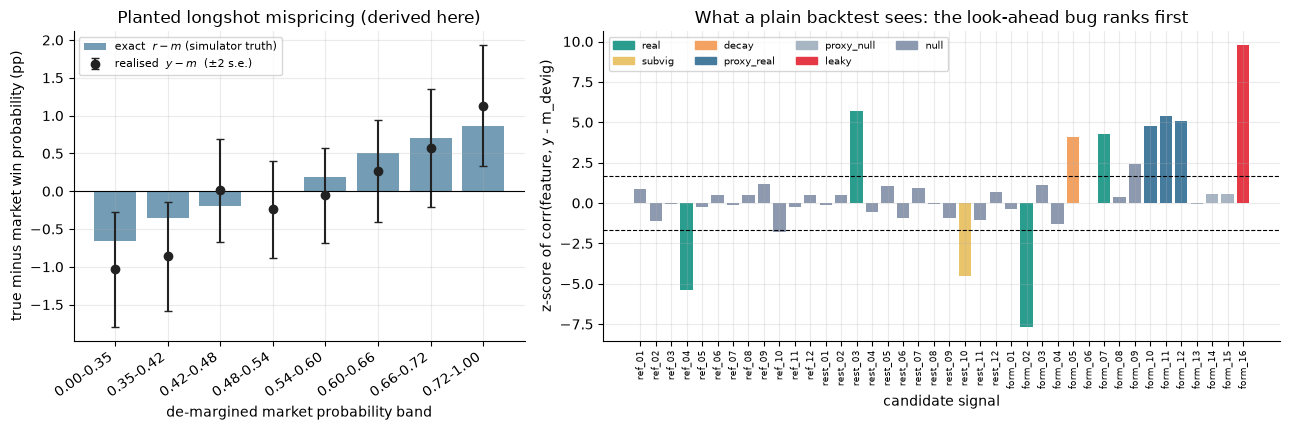

In [7]:
# Visualization only: uses band_tab and zstat_seen computed above.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1, 1.5]))
x = np.arange(len(band_tab))
ax[0].bar(x, band_tab.exact_gap_pp, color=PALETTE["proxy_real"], alpha=0.75, label="exact  $r - m$ (simulator truth)")
ax[0].errorbar(x, band_tab.realised_gap_pp, yerr=2 * band_tab.realised_se_pp, fmt="o", color=PALETTE["market"], capsize=3,
               label="realised  $y - m$  (±2 s.e.)")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xticks(x); ax[0].set_xticklabels(band_tab.band, rotation=35, ha="right")
ax[0].set_xlabel("de-margined market probability band"); ax[0].set_ylabel("true minus market win probability (pp)")
ax[0].set_title("Planted longshot mispricing (derived here)"); ax[0].legend(fontsize=8, loc="upper left")
cols = [PALETTE[c] for c in meta["cls"]]
ax[1].bar(np.arange(40), zstat_seen, color=cols)
ax[1].axhline(1.645, color="k", ls="--", lw=0.8); ax[1].axhline(-1.645, color="k", ls="--", lw=0.8)
ax[1].set_xticks(np.arange(40)); ax[1].set_xticklabels(meta["name"], rotation=90, fontsize=6.5)
ax[1].set_ylabel("z-score of corr(feature, y - m_devig)"); ax[1].set_xlabel("candidate signal")
ax[1].set_title("What a plain backtest sees: the look-ahead bug ranks first")
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[c]) for c in CLASS_ORDER]
ax[1].legend(handles, CLASS_ORDER, ncol=4, fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

## 4. Forecasters: frozen and predictable

Each candidate signal becomes one forecaster,

$$p^{(s)}_g = \sigma\!\big(\operatorname{logit}(m^{\text{devig}}_g) + \hat\theta_s\, z_{s,g}\big),$$

a logistic regression **with the de-margined market as offset** and a single slope $\hat\theta_s$. The slope is fitted by one-dimensional Newton iterations, vectorised over the 40 signals, on **seasons 1-3 only** and then **frozen**. Every forecast is therefore a function of the game's own pre-game information and of a parameter learnt earlier, i.e. it is *predictable*. This matters because the confidence-sequence and e-process results for comparing forecasters that Notebook 3 applies (Choe and Ramdas) are stated for forecasts that are predictable with respect to the game's filtration; a forecaster that peeks at the outcome, or one refitted on the very games it is scored on, is outside their assumptions. The market forecast is simply $m^{\text{devig}}$.

**The truth column.** Because the simulator knows the true win probability $r$, the expected Brier gap of a forecaster $p$ over the market $q$ can be computed exactly, with no sampling noise: $\mathbb E[S(p,y)] = 1-(p-r)^2-r(1-r)$, so

$$\mathbb E\big[S(p,y)-S(q,y)\big] = (q-r)^2-(p-r)^2 .$$

A forecaster is a **true edge** if this gap is positive on the evaluation games. Note what this makes of the leaky signal: its historical feature contains $y$, but its *true* gap, which conditions on pre-game information only, is negative. The realised backtest gap and the true gap of that signal disagree, and the difference is the bug.

In [8]:
# EXPORT: edgelab_fit
import numpy as np

try:
    CFG
except NameError:   # standalone use of this cell
    CFG = dict(train_seasons=3)

def _logit(p):
    p = np.asarray(p, dtype=float)
    return np.log(p / (1.0 - p))

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def fit_forecasters(W, cfg=CFG, iters=8):
    """Frozen single-signal forecasters: forecaster s = sigmoid(logit(m_devig) + theta_hat_s * z_s).
    theta_hat_s comes from a 1-D Newton logistic regression WITH OFFSET logit(m_devig), fitted on the
    training seasons only (vectorised over all signals). Nothing is refitted afterwards, so every
    forecast is a function of information available before tip-off (predictable)."""
    tr = W["season"] <= cfg["train_seasons"]
    off = _logit(W["m_devig"])
    Zt = W["Z"][tr].astype(float)
    yt = W["y"][tr].astype(float)[:, None]
    ot = off[tr][:, None]
    theta = np.zeros(Zt.shape[1])
    for _ in range(iters):
        p = _sigmoid(ot + Zt * theta)
        grad = (Zt * (yt - p)).sum(axis=0)
        hess = (Zt ** 2 * p * (1.0 - p)).sum(axis=0)
        theta = theta + grad / np.maximum(hess, 1e-12)
    P = _sigmoid(off[:, None] + W["Z"].astype(float) * theta[None, :])
    return dict(P=P, theta_hat=theta)

In [9]:
# EXPORT: edgelab_truth
import numpy as np

def true_gap(W, F, by_season=False, mask=None):
    """Exact expected per-game Brier gap (higher-is-better convention) of every frozen forecaster
    versus the de-margined market, averaged over the evaluation games (or over `mask`).
    Given the true win probability r, E[S(p,y)] = 1 - (p-r)^2 - r(1-r), hence
    E[S(p,y) - S(q,y)] = (q-r)^2 - (p-r)^2. Positive means the forecaster truly beats the market.
    by_season=True returns an array (n_eval_seasons, n_signals); row i is season train_seasons+1+i."""
    r, q = W["r_true"], W["m_devig"]
    m = W["eval_mask"] if mask is None else mask
    d = (q - r)[:, None] ** 2 - (F["P"] - r[:, None]) ** 2
    if not by_season:
        return d[m].mean(axis=0)
    seasons = np.unique(W["season"][m])
    return np.vstack([d[m & (W["season"] == s)].mean(axis=0) for s in seasons])

def is_edge(W, F, mask=None):
    """Truth label: a forecaster is a true edge iff its exact expected Brier gap versus the market is positive."""
    return true_gap(W, F, mask=mask) > 0

In [10]:
t0 = time.time()
F = fit_forecasters(W)
P, th_hat = F["P"], F["theta_hat"]
gap_true = true_gap(W, F)
edge = is_edge(W, F)

check("frozen forecasts: shape and range (probabilities strictly inside (0,1))", f"{P.shape}, [{P.min():.3f},{P.max():.3f}]",
      f"({G}, 40), (0,1)", P.shape == (G, 40) and 0 < P.min() and P.max() < 1)

# predictability / freezing test: corrupt every game after game g0 (outcomes, features, odds) and refit.
g0 = int(np.searchsorted(W["season"], 6))          # first game of season 6
Wc = {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in W.items()}
rng = np.random.default_rng(1)
Wc["y"][g0:] = 1 - Wc["y"][g0:]
Wc["Z"][g0:] = rng.standard_normal(Wc["Z"][g0:].shape).astype(np.float32)
Wc["m_devig"][g0:] = rng.uniform(0.2, 0.8, len(Wc["m_devig"]) - g0)
Fc = fit_forecasters(Wc)
check("predictable and frozen: corrupting all games from season 6 on changes nothing before them (max |dP|) and never theta_hat",
      f"{np.abs(Fc['P'][:g0] - P[:g0]).max():.1e}, theta_hat diff {np.abs(Fc['theta_hat'] - th_hat).max():.1e}", "== 0",
      np.array_equal(Fc["P"][:g0], P[:g0]) and np.array_equal(Fc["theta_hat"], th_hat))

# offset logistic regression sanity: the Newton solution zeroes the score equation on the training seasons
tr = W["season"] <= 3
off = np.log(q / (1 - q))
score = (Z[tr] * (y[tr, None] - 1 / (1 + np.exp(-(off[tr, None] + Z[tr] * th_hat))))).sum(axis=0)
check("Newton fit converged: max |score equation| on the training seasons", f"{np.abs(score).max():.1e}", "< 1e-6", np.abs(score).max() < 1e-6)

# estimated slopes against the hidden truth for the clean real edges
real_ids = np.where(meta["cls"] == "real")[0]
se_th = 1 / np.sqrt((Z[tr] ** 2 * 0.25).sum(axis=0))       # approximate standard error of a logit slope
zdev = (th_hat[real_ids] - meta["theta"].values[real_ids]) / se_th[real_ids]
check("estimated slopes of the 4 real edges are within 3 standard errors of the hidden theta (max |z|)", f"{np.abs(zdev).max():.2f}", "< 3",
      np.abs(zdev).max() < 3)

# exact gap versus Monte Carlo: redraw outcomes given r_true and average the realised score differential
ev = W["eval_mask"]
n_rep = 400
rng = np.random.default_rng(2)
Yrep = (rng.random((n_rep, int(ev.sum()))) < r[ev]).astype(float)
Dm = (q[ev, None] ** 2 - P[ev] ** 2)             # (q-y)^2 - (p-y)^2 = (q^2 - p^2) - 2y(q - p)
Bm = 2 * (q[ev, None] - P[ev])
gaps_rep = Dm.mean(axis=0)[None, :] - (Yrep @ Bm) / ev.sum()
mc_mean, mc_se = gaps_rep.mean(axis=0), gaps_rep.std(axis=0, ddof=1) / np.sqrt(n_rep)
ok_ids = np.array([s for s in range(40) if s != leak])
zmc = (mc_mean[ok_ids] - gap_true[ok_ids]) / mc_se[ok_ids]
check("true_gap equals the Monte Carlo average of the realised gap over 400 redrawn outcome vectors (max |z|, 39 non-leaky signals)",
      f"{np.abs(zmc).max():.2f}", "< 4", np.abs(zmc).max() < 4)
check("the market against itself has an exact gap of exactly 0 (true_gap of a forecaster equal to m_devig)",
      f"{true_gap(W, dict(P=np.repeat(q[:, None], 1, axis=1)))[0]:.1e}", "== 0", true_gap(W, dict(P=np.repeat(q[:, None], 1, axis=1)))[0] == 0)

# realised backtest gap and its standard error on the evaluation window (what the client sees)
d_real = score_diff(P, q[:, None], y[:, None])[ev]
gap_real = d_real.mean(axis=0)
se_real = d_real.std(axis=0, ddof=1) / np.sqrt(ev.sum())
check("the leaky signal looks better in the backtest than it truly is: realised gap (x1e4) versus true gap (x1e4)",
      f"{1e4 * gap_real[leak]:+.1f} vs {1e4 * gap_true[leak]:+.1f}", "realised > 0 > true", gap_real[leak] > 0 > gap_true[leak])
tab = pd.DataFrame({"name": meta["name"], "cls": meta["cls"], "theta": meta["theta"].round(3), "theta_hat": th_hat.round(3),
                    "true_gap_x1e4": (1e4 * gap_true).round(2), "is_edge": edge, "realised_gap_x1e4": (1e4 * gap_real).round(2)})
print(tab[tab.cls != "null"].to_string(index=False))
print("nulls: true gap x1e4 mean %.2f, share with is_edge=True %.2f" % (1e4 * gap_true[(meta.cls == "null").values].mean(),
                                                                          edge[(meta.cls == "null").values].mean()))
print(f"(cell time {time.time() - t0:.1f}s)")

SELF-CHECK 15: frozen forecasts: shape and range (probabilities strictly inside (0,1)) -> (14760, 40), [0.091,0.930] (threshold (14760, 40), (0,1)) -> MET
SELF-CHECK 16: predictable and frozen: corrupting all games from season 6 on changes nothing before them (max |dP|) and never theta_hat -> 0.0e+00, theta_hat diff 0.0e+00 (threshold == 0) -> MET
SELF-CHECK 17: Newton fit converged: max |score equation| on the training seasons -> 2.2e-14 (threshold < 1e-6) -> MET
SELF-CHECK 18: estimated slopes of the 4 real edges are within 3 standard errors of the hidden theta (max |z|) -> 1.21 (threshold < 3) -> MET
SELF-CHECK 19: true_gap equals the Monte Carlo average of the realised gap over 400 redrawn outcome vectors (max |z|, 39 non-leaky signals) -> 3.32 (threshold < 4) -> MET
SELF-CHECK 20: the market against itself has an exact gap of exactly 0 (true_gap of a forecaster equal to m_devig) -> 0.0e+00 (threshold == 0) -> MET


SELF-CHECK 21: the leaky signal looks better in the backtest than it truly is: realised gap (x1e4) versus true gap (x1e4) -> +15.9 vs -11.1 (threshold realised > 0 > true) -> MET
   name        cls  theta  theta_hat  true_gap_x1e4  is_edge  realised_gap_x1e4
 ref_04       real -0.122     -0.083           6.75     True               4.66
rest_03       real  0.102      0.099           5.16     True               4.71
rest_10     subvig -0.073     -0.080           2.57     True               3.16
form_02       real -0.143     -0.156           9.84     True               7.12
form_05      decay  0.122      0.128          -5.99    False              -1.93
form_07       real  0.082      0.084           3.12     True               2.05
form_10 proxy_real  0.100      0.084           4.78     True               3.15
form_11 proxy_real  0.100      0.116           4.79     True               2.90
form_12 proxy_real  0.100      0.051           3.89     True               3.83
form_13 proxy_null  0

**How to read this chart**

The x-axis lists the 40 candidate forecasters. Bars are the **exact** expected Brier gap over the market on the evaluation games, in units of $10^{-4}$ Brier points (positive means the forecaster truly beats the de-margined market); the black dots with bars are the **realised** gap the client would see in a backtest, $\pm 2$ standard errors. Look for three things. (1) Real edges (teal) and the real-factor proxies (blue) have positive bars and dots that clear zero, but the dots scatter around the bars by about their error bars: a single backtest is a noisy read of the truth. (2) Nulls have small *negative* bars: adding a slope that is only estimation noise makes a forecast slightly worse than the market, which is why a one-sided test rarely fires on them. (3) The leaky signal (red) has a strongly *positive* dot and a strongly *negative* bar. The backtest gain is an artefact of the bug, and the forecaster is truly worse than the market it will be sold against.

The decaying signal is also negative over the whole evaluation window: its true edge lasted through season 4 only, and the frozen forecaster keeps betting on it afterwards.

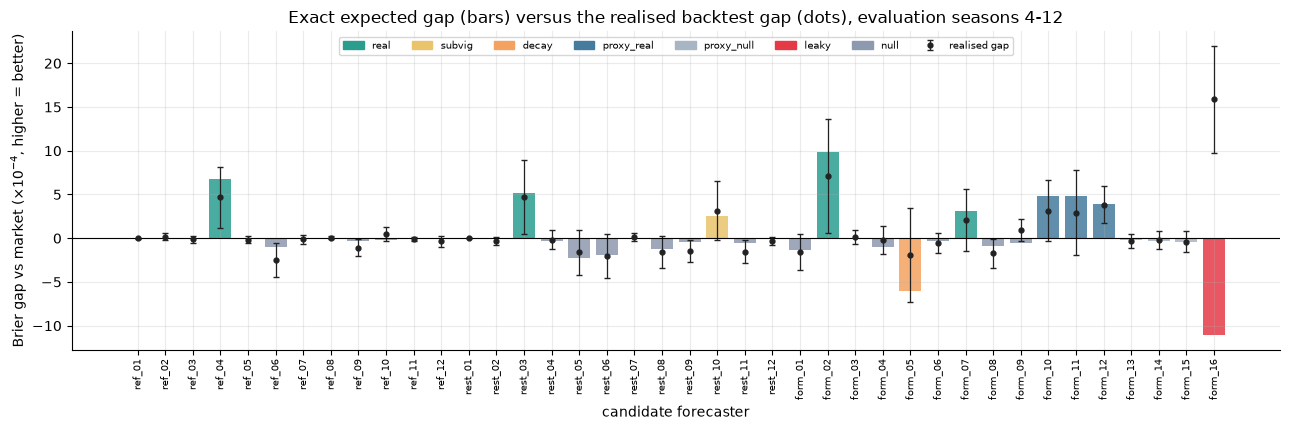

In [11]:
# Visualization only: uses gap_true, gap_real, se_real, meta computed above.
fig, ax = plt.subplots(figsize=(13, 4.4))
x = np.arange(40)
ax.bar(x, 1e4 * gap_true, color=[PALETTE[c] for c in meta["cls"]], alpha=0.85)
ax.errorbar(x, 1e4 * gap_real, yerr=2e4 * se_real, fmt="o", ms=3.5, color=PALETTE["market"], capsize=2, lw=0.9,
            label="realised backtest gap (±2 s.e.)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(meta["name"], rotation=90, fontsize=7)
ax.set_ylabel(r"Brier gap vs market ($\times10^{-4}$, higher = better)"); ax.set_xlabel("candidate forecaster")
ax.set_title("Exact expected gap (bars) versus the realised backtest gap (dots), evaluation seasons 4-12")
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[c]) for c in CLASS_ORDER]
h2, _ = ax.get_legend_handles_labels()
ax.legend(handles + h2, CLASS_ORDER + ["realised gap"], ncol=8, fontsize=7.5, loc="upper center")
plt.tight_layout(); plt.show()

## 5. The client's naive pipeline and its money view

This is the pipeline as the client would run it today, described step by step so the audit can be exact about what it tests.

1. **Backtest screen.** For every signal, a one-sided z-test that its mean Brier differential against the de-margined market is positive on the evaluation window (seasons 4-12). No multiplicity correction, no check that the feature is pre-game.
2. **Publish** every signal with $p<0.05$.
3. **Stack.** Combine the published signals in one logistic regression with the market as offset. The naive version fits the weights on the *same evaluation window* it screened on (in-sample); a variant fits them on the training seasons only. Either way the stack sees whatever the published signals contain, including a leak.
4. **Money view.** Flat unit stake, at the *margined* quoted odds, on the side whose model probability exceeds the break-even probability $1/\text{odds}$ (with a 4.5% overround the break-even sits about 2 points above the fair price, so a bet needs an edge larger than that to pay). ROI is profit divided by the number of bets. It is reported in-sample (the window the stack was fitted on) and **forward** (three live seasons appended after the backtest; in these live seasons the leaky feature no longer contains the outcome, because the outcome is not known before tip-off).

A second rule, **follow**, is also defined for the money view: back the side that the model favours over the market in *every* game. It is the natural reading of "does this signal pay at -110 if you simply follow it" and is used for the sub-vig check below.

**What the papers do and do not say about money.** The comparison of forecasters in Choe and Ramdas is done with proper scoring rules (the Brier score in Sec. 5.2). The three sources do not model profit, bookmaker margin, staking, transaction costs or bet limits, and none of them states that beating a bookmaker's Brier score implies a positive expected return. So in this project a Brier win is *statistical* evidence about forecast quality, and every ROI number is *derived here*, inside the simulator.

In [12]:
# EXPORT: edgelab_money
import numpy as np

def _bets(p, odds_home, odds_away, rule, q):
    p = np.asarray(p, dtype=float)
    oh = odds_home if p.ndim == 1 else odds_home[:, None]
    oa = odds_away if p.ndim == 1 else odds_away[:, None]
    if rule == "edge":            # bet the side whose model probability exceeds the break-even 1/odds
        return p * oh > 1.0, (1.0 - p) * oa > 1.0, oh, oa
    qq = q if p.ndim == 1 else q[:, None]
    return p > qq, p <= qq, oh, oa   # rule == "follow": always back the side the model favours over the market

def roi_flat(p_model, odds_home, odds_away, y, mask=None, rule="edge", q=None):
    """Realised flat-stake return: unit stake on the side whose model probability exceeds the break-even
    probability 1/odds (rule='edge'), at the margined quoted decimal odds. p_model may be (G,) or (G, n).
    Returns dict(roi, n_bets, profit, hit_rate, n_home, n_away)."""
    p = np.asarray(p_model, dtype=float)
    bh, ba, oh, oa = _bets(p, odds_home, odds_away, rule, q)
    yy = np.asarray(y)[:, None] if p.ndim == 2 else np.asarray(y)
    m = slice(None) if mask is None else mask
    win_h = np.where(yy == 1, oh - 1.0, -1.0) * bh
    win_a = np.where(yy == 0, oa - 1.0, -1.0) * ba
    n_home, n_away = bh[m].sum(axis=0), ba[m].sum(axis=0)
    n_bets = n_home + n_away
    profit = win_h[m].sum(axis=0) + win_a[m].sum(axis=0)
    wins = ((yy == 1) * bh + (yy == 0) * ba)[m].sum(axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        return dict(roi=profit / n_bets, n_bets=n_bets, profit=profit, hit_rate=wins / n_bets,
                    n_home=n_home, n_away=n_away)

def expected_roi_flat(p_model, odds_home, odds_away, r_true, mask=None, rule="edge", q=None):
    """Exact expected flat-stake ROI of the same betting rule, using the true win probability r_true
    (expected profit of a home bet is r*odds - 1, of an away bet (1-r)*odds - 1)."""
    p = np.asarray(p_model, dtype=float)
    bh, ba, oh, oa = _bets(p, odds_home, odds_away, rule, q)
    r = np.asarray(r_true)[:, None] if p.ndim == 2 else np.asarray(r_true)
    m = slice(None) if mask is None else mask
    ev = (r * oh - 1.0) * bh + ((1.0 - r) * oa - 1.0) * ba
    n_bets = (bh[m].sum(axis=0) + ba[m].sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        return dict(roi=ev[m].sum(axis=0) / n_bets, n_bets=n_bets, profit=ev[m].sum(axis=0))

In [13]:
# EXPORT: edgelab_naive
import numpy as np
from math import erfc, sqrt

def _logit(p):
    p = np.asarray(p, dtype=float)
    return np.log(p / (1.0 - p))

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def stack_fit(offset, X, y, l2=1e-3, iters=25):
    """Logistic regression with a fixed offset (the market logit), Newton with a tiny ridge:
    the client's way of 'stacking' the winning signals."""
    beta = np.zeros(X.shape[1])
    for _ in range(iters):
        p = _sigmoid(offset + X @ beta)
        grad = X.T @ (y - p) - l2 * beta
        H = (X * (p * (1.0 - p))[:, None]).T @ X + l2 * np.eye(X.shape[1])
        step = np.linalg.solve(H, grad)
        beta = beta + step
        if np.max(np.abs(step)) < 1e-8:
            break
    return beta

def stack_predict(offset, X, beta):
    return _sigmoid(offset + X @ beta)

def naive_screen(W, F, alpha=0.05, fit_on="eval", mask=None):
    """The client's backtest. For every signal: one-sided z-test that the mean Brier differential versus the
    de-margined market is positive on the evaluation window (no multiplicity correction, no look-ahead check).
    Signals with p < alpha are 'published' and stacked (logistic regression with offset on the chosen window).
    Returns dict(pvals, selected, stack_P, stack_P_train, beta, tstat, gap_hat)."""
    m = W["eval_mask"] if mask is None else mask
    y, q = W["y"].astype(float), W["m_devig"]
    d = (1.0 - (F["P"] - y[:, None]) ** 2) - (1.0 - (q - y) ** 2)[:, None]
    dm = d[m]
    gap = dm.mean(axis=0)
    se = dm.std(axis=0, ddof=1) / np.sqrt(dm.shape[0])
    tstat = gap / np.maximum(se, 1e-15)
    pvals = np.array([0.5 * erfc(t / sqrt(2.0)) for t in tstat])       # one-sided normal p-value
    selected = pvals < alpha
    off = _logit(q)
    Zs = W["Z"][:, selected].astype(float)
    if selected.sum() == 0:
        return dict(pvals=pvals, selected=selected, stack_P=q.copy(), stack_P_train=q.copy(),
                    beta=np.zeros(0), tstat=tstat, gap_hat=gap)
    fit_mask = m if fit_on == "eval" else (W["season"] <= (W["season"][W["eval_mask"]].min() - 1))
    beta = stack_fit(off[fit_mask], Zs[fit_mask], y[fit_mask])
    tr = W["season"] <= (W["season"][W["eval_mask"]].min() - 1)
    beta_tr = stack_fit(off[tr], Zs[tr], y[tr])
    return dict(pvals=pvals, selected=selected, stack_P=stack_predict(off, Zs, beta),
                stack_P_train=stack_predict(off, Zs, beta_tr), beta=beta, tstat=tstat, gap_hat=gap)

In [14]:
t0 = time.time()
CFG_LIVE = {**CFG, "forward_seasons": 3}          # showcase and audit worlds: 12 historical seasons + 3 live seasons
WS = simulate_world(SEED_SHOWCASE, CFG_LIVE)
FS = fit_forecasters(WS, CFG_LIVE)
mS = WS["meta"]
ns = naive_screen(WS, FS, alpha=0.05)
gS = true_gap(WS, FS)
eS = gS > 0
evS, fwS = WS["eval_mask"], WS["fwd_mask"]
qS, yS, rS = WS["m_devig"], WS["y"].astype(float), WS["r_true"]
ohS, oaS = WS["odds_home"], WS["odds_away"]

check("naive_screen: p-values in [0,1] and selected == (p < 0.05)", f"[{ns['pvals'].min():.4f}, {ns['pvals'].max():.4f}], {int(ns['selected'].sum())} selected",
      "[0,1]", ns["pvals"].min() >= 0 and ns["pvals"].max() <= 1 and np.array_equal(ns["selected"], ns["pvals"] < 0.05))
check("stack forecasts are proper probabilities in (0,1), both weight-fitting windows", f"[{min(ns['stack_P'].min(), ns['stack_P_train'].min()):.3f}, {max(ns['stack_P'].max(), ns['stack_P_train'].max()):.3f}]",
      "(0,1)", 0 < min(ns["stack_P"].min(), ns["stack_P_train"].min()) and max(ns["stack_P"].max(), ns["stack_P_train"].max()) < 1)

# roi_flat against a hand computation on a toy slate of three games
toy = roi_flat(np.array([0.60, 0.40, 0.50]), np.array([1.80, 1.80, 1.95]), np.array([2.10, 2.10, 1.95]), np.array([1, 1, 0]))
# game 1: 0.60*1.80=1.08>1 -> bet home, home wins -> +0.80; game 2: home 0.40*1.8<1, away 0.60*2.1=1.26>1 -> bet away, home wins -> -1; game 3: no bet
check("roi_flat on a hand-worked toy slate (2 bets, profit +0.80 - 1 = -0.20, roi -0.10)", f"n_bets {int(toy['n_bets'])}, profit {toy['profit']:+.2f}, roi {toy['roi']:+.2f}",
      "2, -0.20, -0.10", int(toy["n_bets"]) == 2 and abs(toy["profit"] + 0.20) < 1e-12 and abs(toy["roi"] + 0.10) < 1e-12)
# on the market itself the break-even rule never bets (margin makes 1/odds exceed the fair price on both sides)
mk = roi_flat(qS, ohS, oaS, WS["y"])
check("betting the de-margined market forecast at the margined odds places no bets (overround kills every edge)", f"{int(mk['n_bets'])} bets", "0", int(mk["n_bets"]) == 0)

# realised forward ROI of the stack against its exact expectation (uses r_true; only meaningful out of sample)
res = {}
for tag, Pst in (("in-sample stack", ns["stack_P"]), ("train-fit stack", ns["stack_P_train"])):
    a, b = roi_flat(Pst, ohS, oaS, WS["y"], mask=evS), roi_flat(Pst, ohS, oaS, WS["y"], mask=fwS)
    eb = expected_roi_flat(Pst, ohS, oaS, rS, mask=fwS)
    res[tag] = (a, b, eb)
a, b, eb = res["in-sample stack"]
se_b = 1.3 / np.sqrt(b["n_bets"])
check("forward realised ROI of the stack equals its exact expected ROI within 4 standard errors (|diff| / se)", f"{abs(b['roi'] - eb['roi']) / se_b:.2f}", "< 4",
      abs(b["roi"] - eb["roi"]) / se_b < 4)

sel_names = list(mS["name"][ns["selected"]])
print("published by the naive screen:", ", ".join(f"{n} [{c}]" for n, c in zip(sel_names, mS["cls"][ns["selected"]])))
for tag, (a, b, eb) in res.items():
    print(f"{tag:16s} in-sample ROI {100 * a['roi']:+5.1f}% ({int(a['n_bets'])} bets) | forward ROI {100 * b['roi']:+5.1f}% ({int(b['n_bets'])} bets), exact expected forward ROI {100 * eb['roi']:+5.1f}%")
truth_tab = mS.assign(theta_hat=FS["theta_hat"], true_gap_x1e4=1e4 * gS, is_edge=eS, p_value=ns["pvals"], published=ns["selected"])
truth_tab = truth_tab[["name", "family", "cls", "theta", "eff_pp", "theta_hat", "true_gap_x1e4", "is_edge", "p_value", "published"]].round(4)
print("\nShowcase truth table (non-null signals plus every published one):")
print(truth_tab[(truth_tab.cls != "null") | truth_tab.published].to_string())

# curves for the figure: cumulative realised and exact Brier gain by class over the evaluation games (class mean of the signals),
# and cumulative profit of the naive stack over the backtest and the live seasons
clsS = mS["cls"].values
dS = score_diff(FS["P"], qS[:, None], yS[:, None])
xS = (qS - rS)[:, None] ** 2 - (FS["P"] - rS[:, None]) ** 2
cum_real = {c: np.cumsum(dS[evS][:, clsS == c].mean(axis=1)) for c in CLASS_ORDER}
cum_exact = {c: np.cumsum(xS[evS][:, clsS == c].mean(axis=1)) for c in CLASS_ORDER}
season_ev = WS["season"][evS]
def game_profit(Pst):
    bh, ba = Pst * ohS > 1, (1 - Pst) * oaS > 1
    return bh * np.where(yS == 1, ohS - 1, -1.0) + ba * np.where(yS == 0, oaS - 1, -1.0), bh | ba
prof_in, bet_in = game_profit(ns["stack_P"])
hor = evS | fwS
cum_profit = np.cumsum(prof_in[hor])
n_backtest = int(evS.sum())
print(f"(cell time {time.time() - t0:.1f}s)")

SELF-CHECK 22: naive_screen: p-values in [0,1] and selected == (p < 0.05) -> [0.0000, 0.9993], 8 selected (threshold [0,1]) -> MET
SELF-CHECK 23: stack forecasts are proper probabilities in (0,1), both weight-fitting windows -> [0.082, 0.926] (threshold (0,1)) -> MET
SELF-CHECK 24: roi_flat on a hand-worked toy slate (2 bets, profit +0.80 - 1 = -0.20, roi -0.10) -> n_bets 2, profit -0.20, roi -0.10 (threshold 2, -0.20, -0.10) -> MET
SELF-CHECK 25: betting the de-margined market forecast at the margined odds places no bets (overround kills every edge) -> 0 bets (threshold 0) -> MET
SELF-CHECK 26: forward realised ROI of the stack equals its exact expected ROI within 4 standard errors (|diff| / se) -> 0.79 (threshold < 4) -> MET
published by the naive screen: ref_04 [real], rest_03 [real], rest_10 [subvig], form_02 [real], form_10 [proxy_real], form_11 [proxy_real], form_12 [proxy_real], form_16 [leaky]
in-sample stack  in-sample ROI +11.3% (8527 bets) | forward ROI  +3.3% (2826 bets), e

**How to read this chart**

*Left panel.* The x-axis is games in the evaluation window (seasons 4-12, in time order). Each solid line is the **realised** cumulative Brier gain over the market, averaged over the signals of one class (higher is better); the dashed line of the same colour is the **exact** expected cumulative gain from the simulator's truth. Solid and dashed agree for honest classes, with the solid line wandering around the dashed one. Two lines break the pattern by design: the **leaky** class (red) climbs in the backtest although its exact gain falls, and the **decay** class (orange) has a real edge only in season 4 (the first ~1,230 games; on this scale the small early gain is invisible, see the by-season chart below) and falls steadily once the edge has switched off, because the frozen forecaster keeps betting on it. Real edges climb slowly and unevenly: even a true 2-3 point edge needs thousands of games to separate cleanly from noise. Null signals stay flat or slip.

*Right panel.* Cumulative profit in units of the naive stack (flat stake at the margined odds, threshold rule), over the nine backtest seasons and then three live seasons (vertical line). The weights were fitted on the backtest window, so the backtest slope is the **in-sample** figure and the live slope is **forward**. The slope softens at the line: that softening is the optimism the client's current view builds in; the stack's exact expected forward ROI is printed above. One showcase world is one draw: the distribution over 200 worlds comes next.

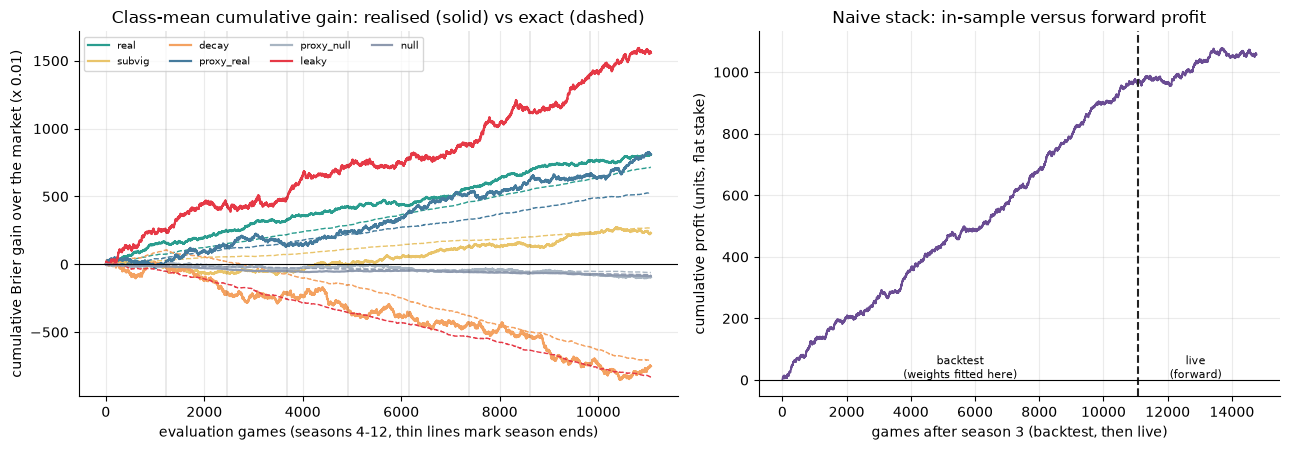

In [15]:
# Visualization only: uses cum_real, cum_exact, cum_profit computed above (showcase world).
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
gx = np.arange(1, n_backtest + 1)
for c in CLASS_ORDER:
    ax[0].plot(gx, 1e2 * cum_real[c], color=PALETTE[c], lw=1.6, label=c)
    ax[0].plot(gx, 1e2 * cum_exact[c], color=PALETTE[c], lw=1.0, ls="--")
ax[0].axhline(0, color="k", lw=0.8)
for s in range(1, 9):
    ax[0].axvline(1230 * s, color="k", lw=0.3, alpha=0.4)
ax[0].set_xlabel("evaluation games (seasons 4-12, thin lines mark season ends)")
ax[0].set_ylabel("cumulative Brier gain over the market (x 0.01)")
ax[0].set_title("Class-mean cumulative gain: realised (solid) vs exact (dashed)")
ax[0].legend(ncol=4, fontsize=7.5, loc="upper left")
ax[1].plot(np.arange(1, len(cum_profit) + 1), cum_profit, color=PALETTE["stack"], lw=1.4)
ax[1].axvline(n_backtest, color=PALETTE["market"], ls="--")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].text(n_backtest * 0.5, 0.04, "backtest\n(weights fitted here)", ha="center", va="bottom", fontsize=8, transform=ax[1].get_xaxis_transform())
ax[1].text(n_backtest + 1800, 0.04, "live\n(forward)", ha="center", va="bottom", fontsize=8, transform=ax[1].get_xaxis_transform())
ax[1].set_xlabel("games after season 3 (backtest, then live)")
ax[1].set_ylabel("cumulative profit (units, flat stake)")
ax[1].set_title("Naive stack: in-sample versus forward profit")
plt.tight_layout(); plt.show()

## 6. Baseline audit: the naive pipeline against the known truth

One showcase world proves little. The audit repeats the naive pipeline in **200 independent worlds** (one seed each; each world redraws schedule, team strengths, referees, features, effect signs, market noise and outcomes; the class layout is fixed so power can be reported by class). In each world the pipeline runs exactly as described above, and the known truth scores it:

* **published** = $p<0.05$ in the backtest screen; **true edge** = exact expected gap $>0$ on the evaluation window (`is_edge`); **false discovery** = published and not a true edge; **FDP** = false discoveries / max(published, 1), and the false-discovery *rate* is its mean over worlds;
* **power by class** = share of the class's signals that are published;
* **honest intervals**: proportions over worlds carry Wilson 95% intervals; means over worlds carry percentile-bootstrap 95% intervals that resample whole worlds (signals inside a world share data, so they are not treated as independent);
* **money**: for the stack, ROI in-sample (window it was fitted and screened on) versus forward (three live seasons per world), at the margined odds with the threshold rule; and, exactly from the truth, the expected ROI of each single-signal forecaster under the threshold rule and the follow rule.

The cache is `data/nb02_audit_200worlds.npz` (regenerated if absent; about a minute and a half).

In [16]:
t0 = time.time()
def audit_one_world(seed, cfg):
    """Full naive pipeline in one world, scored against the known truth."""
    Wa = simulate_world(seed, cfg)
    Fa = fit_forecasters(Wa, cfg)
    na = naive_screen(Wa, Fa, alpha=0.05)
    m_ev, m_fw = Wa["eval_mask"], Wa["fwd_mask"]
    qa, oh, oa, ya, ra = Wa["m_devig"], Wa["odds_home"], Wa["odds_away"], Wa["y"], Wa["r_true"]
    rec = dict(pvals=na["pvals"], selected=na["selected"], gap=true_gap(Wa, Fa), gap_by_season=true_gap(Wa, Fa, by_season=True),
               theta=Wa["meta"]["theta"].values, theta_hat=Fa["theta_hat"])
    e_thr = expected_roi_flat(Fa["P"], oh, oa, ra, mask=m_ev)
    e_fol = expected_roi_flat(Fa["P"], oh, oa, ra, mask=m_ev, rule="follow", q=qa)
    rec.update(roi_thr=e_thr["roi"], nb_thr=e_thr["n_bets"], roi_fol=e_fol["roi"])
    for tag, Pst in (("in", na["stack_P"]), ("tr", na["stack_P_train"])):
        a, b = roi_flat(Pst, oh, oa, ya, mask=m_ev), roi_flat(Pst, oh, oa, ya, mask=m_fw)
        rec[f"roi_{tag}_eval"], rec[f"nb_{tag}_eval"] = a["roi"], a["n_bets"]
        rec[f"roi_{tag}_fwd"], rec[f"nb_{tag}_fwd"] = b["roi"], b["n_bets"]
        dd = score_diff(Pst, qa, ya)
        rec[f"bgap_{tag}_eval"], rec[f"bgap_{tag}_fwd"] = dd[m_ev].mean(), dd[m_fw].mean()
        dt = (qa - ra) ** 2 - (Pst - ra) ** 2
        rec[f"tgap_{tag}_eval"], rec[f"tgap_{tag}_fwd"] = dt[m_ev].mean(), dt[m_fw].mean()
    return rec

cache = DATA_DIR / "nb02_audit_200worlds.npz"
signature = repr(sorted(CFG_LIVE.items())) + f"|{AUDIT_SEEDS[0]}-{AUDIT_SEEDS[-1]}|v1"
A, from_cache = None, False
if cache.exists():
    z = np.load(cache, allow_pickle=False)
    if str(z["signature"]) == signature:
        A = {k: z[k] for k in z.files if k != "signature"}
        from_cache = True
if A is None:
    recs = [audit_one_world(int(s), CFG_LIVE) for s in AUDIT_SEEDS]
    A = {k: np.array([rec[k] for rec in recs]) for k in recs[0]}
    np.savez(cache, signature=np.array(signature), **A)
print(f"audit: {len(AUDIT_SEEDS)} worlds, {'loaded from cache' if from_cache else 'simulated'} ({time.time() - t0:.0f}s)")

# integrity: re-running one world from scratch reproduces its cached record
chk = audit_one_world(int(AUDIT_SEEDS[7]), CFG_LIVE)
check("cache integrity: re-running world #8 reproduces the stored p-values, selection and exact gaps",
      f"max |dp| {np.abs(chk['pvals'] - A['pvals'][7]).max():.1e}", "== 0",
      np.array_equal(chk["selected"], A["selected"][7]) and np.allclose(chk["pvals"], A["pvals"][7], atol=1e-12) and np.allclose(chk["gap"], A["gap"][7], atol=1e-12))
check("audit size and validity: worlds, p-values in [0,1]", f"{A['pvals'].shape[0]} worlds, p in [{A['pvals'].min():.3f},{A['pvals'].max():.3f}]", "200 worlds, [0,1]",
      A["pvals"].shape == (200, 40) and A["pvals"].min() >= 0 and A["pvals"].max() <= 1)

cls = mS["cls"].values
sel = A["selected"].astype(bool)
is_edge_w = A["gap"] > 0
npub = sel.sum(axis=1)
tp = (sel & is_edge_w).sum(axis=1)
fdp = np.where(npub > 0, (npub - tp) / np.maximum(npub, 1), 0.0)
prec = np.where(npub > 0, tp / np.maximum(npub, 1), np.nan)
no_effect = np.isin(cls, ["null", "proxy_null", "leaky"])
fp_noeffect = sel[:, no_effect].sum(axis=1)
leaky_pub = sel[:, cls == "leaky"][:, 0]
real_found = sel[:, cls == "real"].sum(axis=1)
edge_cls = np.isin(cls, ["real", "subvig", "proxy_real"])
fdp_cls = np.where(npub > 0, sel[:, ~edge_cls].sum(axis=1) / np.maximum(npub, 1), 0.0)

rows = []
def add(name, arr, fmt="{:.3f}"):
    m, lo, hi = boot_ci(arr)
    rows.append((name, fmt.format(m), f"[{fmt.format(lo)}, {fmt.format(hi)}]"))
add("signals published per world", npub, "{:.2f}")
add("of which false positives among the 31 no-effect signals", fp_noeffect, "{:.2f}")
add("precision (true edges / published), worlds with >= 1 published", prec, "{:.3f}")
add("false-discovery proportion, is_edge labelling (mean over worlds)", fdp)
add("false-discovery proportion, class labelling (mean over worlds)", fdp_cls)
kl, (wl, wh) = int(leaky_pub.sum()), wilson(int(leaky_pub.sum()), 200)
rows.append(("leaky signal published (share of worlds)", f"{kl / 200:.3f}", f"[{wl:.3f}, {wh:.3f}] Wilson"))
k4 = int((real_found == 4).sum()); w4 = wilson(k4, 200)
rows.append(("all 4 real edges published (share of worlds)", f"{k4 / 200:.3f}", f"[{w4[0]:.3f}, {w4[1]:.3f}] Wilson"))
kz = int((fdp == 0).sum()); wz = wilson(kz, 200)
rows.append(("worlds with zero false discoveries", f"{kz / 200:.3f}", f"[{wz[0]:.3f}, {wz[1]:.3f}] Wilson"))
print(pd.DataFrame(rows, columns=["baseline metric", "estimate", "95% interval"]).to_string(index=False))

# power by class (share of the class's signals published), with exact truth summaries
crow = []
for c in CLASS_ORDER:
    m = cls == c
    pw = sel[:, m].mean(axis=1)
    mean_pw, lo, hi = boot_ci(pw)
    g_m, g_lo, g_hi = boot_ci(A["gap"][:, m].mean(axis=1))
    crow.append(dict(cls=c, n=int(m.sum()), published_share=round(mean_pw, 3), ci=f"[{lo:.3f}, {hi:.3f}]",
                     true_gap_x1e4=round(1e4 * g_m, 2), share_is_edge=round(is_edge_w[:, m].mean(), 3),
                     exact_ROI_threshold_pct=round(100 * np.nanmean(A["roi_thr"][:, m]), 2),
                     exact_ROI_follow_pct=round(100 * np.nanmean(A["roi_fol"][:, m]), 2),
                     mean_bets_threshold=int(np.nanmean(A["nb_thr"][:, m]))))
print(); print(pd.DataFrame(crow).to_string(index=False))

audit: 200 worlds, loaded from cache (0s)


SELF-CHECK 27: cache integrity: re-running world #8 reproduces the stored p-values, selection and exact gaps -> max |dp| 0.0e+00 (threshold == 0) -> MET
SELF-CHECK 28: audit size and validity: worlds, p-values in [0,1] -> 200 worlds, p in [0.000,1.000] (threshold 200 worlds, [0,1]) -> MET


                                                 baseline metric estimate          95% interval
                                     signals published per world     7.22          [6.98, 7.46]
         of which false positives among the 31 no-effect signals     1.43          [1.32, 1.52]
  precision (true edges / published), worlds with >= 1 published    0.813        [0.801, 0.825]
false-discovery proportion, is_edge labelling (mean over worlds)    0.187        [0.175, 0.199]
  false-discovery proportion, class labelling (mean over worlds)    0.199        [0.186, 0.213]
                        leaky signal published (share of worlds)    0.955 [0.917, 0.976] Wilson
                    all 4 real edges published (share of worlds)    0.305 [0.245, 0.372] Wilson
                              worlds with zero false discoveries    0.045 [0.024, 0.083] Wilson



       cls  n  published_share             ci  true_gap_x1e4  share_is_edge  exact_ROI_threshold_pct  exact_ROI_follow_pct  mean_bets_threshold
      real  4            0.751 [0.721, 0.781]           6.16          0.989                     3.00                 -0.44                 4073
    subvig  1            0.595 [0.525, 0.660]           2.20          0.970                     1.99                 -1.95                 2315
     decay  1            0.005 [0.000, 0.015]          -6.81          0.015                    -3.99                 -4.10                 4511
proxy_real  3            0.732 [0.682, 0.780]           4.50          0.993                     2.77                 -0.87                 3564
proxy_null  3            0.008 [0.002, 0.018]          -0.65          0.038                    -6.11                 -4.60                  385
     leaky  1            0.955 [0.925, 0.980]         -13.43          0.000                    -4.63                 -4.47             

In [17]:
print("--- design targets of the simulator (i)-(iv), evaluated over the 200 audit worlds ---")
m_fp, lo_fp, hi_fp = boot_ci(fp_noeffect)
check("(i-a) naive screen false positives among the 31 no-effect signals, mean per world [95% bootstrap]", f"{m_fp:.2f} [{lo_fp:.2f}, {hi_fp:.2f}]",
      "mean in [1, 3]", 1.0 <= m_fp <= 3.0)
m_rf = real_found.mean()
check("(i-b) real edges found by the naive screen (of 4): finds some, not all -- mean found; share of worlds finding all four", f"{m_rf:.2f}; {k4 / 200:.2f}",
      "0 < mean < 4 and share(all four) < 0.9", 0 < m_rf < 4 and k4 / 200 < 0.9)
exact = np.array([set(np.where(row)[0]) == set(np.where(cls == "real")[0]) for row in sel])
check("(i-c) world is not too easy: share of worlds where the published set is exactly the 4 real edges", f"{exact.mean():.3f}", "< 0.10", exact.mean() < 0.10)
check("(ii) the leaky signal is selected by the naive screen: share of worlds [Wilson 95%]", f"{kl / 200:.3f} [{wl:.3f}, {wh:.3f}]", ">= 0.95", kl / 200 >= 0.95)
sv = cls == "subvig"
g_m, g_lo, g_hi = boot_ci(A["gap"][:, sv][:, 0])
f_m, f_lo, f_hi = boot_ci(A["roi_fol"][:, sv][:, 0])
t_m = np.nanmean(A["roi_thr"][:, sv][:, 0]); t_n = A["nb_thr"][:, sv][:, 0].mean()
check("(iii-a) SUBVIG expected Brier gain (x1e4) is positive: mean [95% bootstrap]", f"{1e4 * g_m:.2f} [{1e4 * g_lo:.2f}, {1e4 * g_hi:.2f}]", "lower end > 0", g_lo > 0)
check("(iii-b) SUBVIG expected flat-stake ROI at the margined odds when the signal is followed every game (%) [95% bootstrap]",
      f"{100 * f_m:.2f} [{100 * f_lo:.2f}, {100 * f_hi:.2f}]", "upper end < 0", f_hi < 0)
print(f"      (information, not a check: with the threshold rule the same forecaster bets only ~{t_n:.0f} of 11,070 games, in the tail where its edge clears the overround,"
      f" and its exact expected ROI there is {100 * t_m:+.2f}%. A sub-vig edge does not pay when followed; it can pay in its tail.)")
dc = cls == "decay"
gs = A["gap_by_season"][:, :, dc][:, :, 0]         # (worlds, 9 evaluation seasons)
s4_m, s4_lo, s4_hi = boot_ci(gs[:, 0])
late_m, late_lo, late_hi = boot_ci(gs[:, 2:].mean(axis=1))
dec_ci = [boot_ci(gs[:, k]) for k in range(gs.shape[1])]        # exact DECAY gap by evaluation season, mean and 95% bootstrap over worlds
sv_gs = A["gap_by_season"][:, :, sv][:, :, 0]
sub_ci = [boot_ci(sv_gs[:, k]) for k in range(sv_gs.shape[1])]
print("exact gap (x1e4) by evaluation season 4..12, mean over worlds:")
print("  decay :", " ".join(f"{1e4 * c[0]:6.2f}" for c in dec_ci))
print("  subvig:", " ".join(f"{1e4 * c[0]:6.2f}" for c in sub_ci))
check("(iv-a) DECAY exact gap (x1e4) in the first evaluation season (season 4) is positive: mean [95% bootstrap]", f"{1e4 * s4_m:.2f} [{1e4 * s4_lo:.2f}, {1e4 * s4_hi:.2f}]",
      "lower end > 0", s4_lo > 0)
check("(iv-b) DECAY exact gap (x1e4) in seasons 6-12 is not positive (the edge is gone; the frozen forecaster keeps using it, so the gap is negative rather than 0)",
      f"{1e4 * late_m:.2f} [{1e4 * late_lo:.2f}, {1e4 * late_hi:.2f}]", "upper end <= 0", late_hi <= 0)

print("\n--- baseline scored against the acceptance criteria (naive pipeline; a FAIL is a finding, not a self-check failure) ---")
m_fdp, lo_fdp, hi_fdp = boot_ci(fdp)
print(f"BASELINE AC1: mean false-discovery proportion {m_fdp:.3f} [{lo_fdp:.3f}, {hi_fdp:.3f}] (target <= 0.100) -> {'PASS' if hi_fdp <= 0.10 else 'FAIL'}")
print(f"BASELINE AC2: a look-ahead (predictability-violating) signal is published in {kl / 200:.3f} of worlds [{wl:.3f}, {wh:.3f}] (target <= 0.010) -> {'PASS' if wh <= 0.01 else 'FAIL'}")
ns_pub_leak_share = float(sel[:, cls == "leaky"].sum() / max(sel.sum(), 1))
print(f"      the leaky signal accounts for {100 * ns_pub_leak_share:.0f}% of all published signals; every false discovery beyond it is a null signal that fired by chance.")

print("\n--- the stack and the honest money view (threshold rule, margined odds), over the 200 worlds ---")
mrows = []
for tag, lab in (("in", "stack fitted on the backtest window (in-sample)"), ("tr", "stack fitted on training seasons only")):
    ev_roi, fw_roi = A[f"roi_{tag}_eval"], A[f"roi_{tag}_fwd"]
    diff = ev_roi - fw_roi
    e = boot_ci(ev_roi); f = boot_ci(fw_roi); d = boot_ci(diff)
    bg_e, bg_f = boot_ci(A[f"bgap_{tag}_eval"]), boot_ci(A[f"bgap_{tag}_fwd"])
    tg_f = boot_ci(A[f"tgap_{tag}_fwd"])
    mrows.append(dict(stack=lab, roi_backtest_pct=f"{100 * e[0]:.2f} [{100 * e[1]:.2f}, {100 * e[2]:.2f}]",
                      roi_forward_pct=f"{100 * f[0]:.2f} [{100 * f[1]:.2f}, {100 * f[2]:.2f}]",
                      optimism_gap_pts=f"{100 * d[0]:.2f} [{100 * d[1]:.2f}, {100 * d[2]:.2f}]",
                      share_worlds_backtest_above_forward=round(float((diff > 0).mean()), 3),
                      realised_brier_gap_backtest_x1e4=round(1e4 * bg_e[0], 1), realised_brier_gap_forward_x1e4=round(1e4 * bg_f[0], 1),
                      exact_brier_gap_forward_x1e4=round(1e4 * tg_f[0], 1),
                      bets_backtest=int(A[f"nb_{tag}_eval"].mean()), bets_forward=int(A[f"nb_{tag}_fwd"].mean())))
print(pd.DataFrame(mrows).T.to_string(header=False))
gap_in = A["roi_in_eval"] - A["roi_in_fwd"]
lk = leaky_pub.astype(bool)
print(f"\noptimism gap when the leaky signal is in the stack: {100 * gap_in[lk].mean():.2f} pts ({lk.sum()} worlds); when it is not: "
      f"{100 * gap_in[~lk].mean():.2f} pts ({(~lk).sum()} worlds)" if (~lk).sum() > 0 else "\nthe leaky signal is in the stack in every world")
print(f"(cell time {time.time() - t0:.1f}s)")

--- design targets of the simulator (i)-(iv), evaluated over the 200 audit worlds ---
SELF-CHECK 29: (i-a) naive screen false positives among the 31 no-effect signals, mean per world [95% bootstrap] -> 1.43 [1.32, 1.52] (threshold mean in [1, 3]) -> MET
SELF-CHECK 30: (i-b) real edges found by the naive screen (of 4): finds some, not all -- mean found; share of worlds finding all four -> 3.00; 0.30 (threshold 0 < mean < 4 and share(all four) < 0.9) -> MET
SELF-CHECK 31: (i-c) world is not too easy: share of worlds where the published set is exactly the 4 real edges -> 0.000 (threshold < 0.10) -> MET
SELF-CHECK 32: (ii) the leaky signal is selected by the naive screen: share of worlds [Wilson 95%] -> 0.955 [0.917, 0.976] (threshold >= 0.95) -> MET


SELF-CHECK 33: (iii-a) SUBVIG expected Brier gain (x1e4) is positive: mean [95% bootstrap] -> 2.20 [2.08, 2.31] (threshold lower end > 0) -> MET
SELF-CHECK 34: (iii-b) SUBVIG expected flat-stake ROI at the margined odds when the signal is followed every game (%) [95% bootstrap] -> -1.95 [-2.08, -1.84] (threshold upper end < 0) -> MET
      (information, not a check: with the threshold rule the same forecaster bets only ~2315 of 11,070 games, in the tail where its edge clears the overround, and its exact expected ROI there is +1.99%. A sub-vig edge does not pay when followed; it can pay in its tail.)


exact gap (x1e4) by evaluation season 4..12, mean over worlds:
  decay :   6.98  -8.61  -8.65  -8.47  -8.56  -8.63  -8.49  -8.57  -8.31
  subvig:   2.23   2.13   2.16   2.14   2.27   2.32   2.10   2.21   2.22
SELF-CHECK 35: (iv-a) DECAY exact gap (x1e4) in the first evaluation season (season 4) is positive: mean [95% bootstrap] -> 6.98 [6.69, 7.25] (threshold lower end > 0) -> MET
SELF-CHECK 36: (iv-b) DECAY exact gap (x1e4) in seasons 6-12 is not positive (the edge is gone; the frozen forecaster keeps using it, so the gap is negative rather than 0) -> -8.53 [-9.21, -7.91] (threshold upper end <= 0) -> MET

--- baseline scored against the acceptance criteria (naive pipeline; a FAIL is a finding, not a self-check failure) ---
BASELINE AC1: mean false-discovery proportion 0.187 [0.175, 0.199] (target <= 0.100) -> FAIL
BASELINE AC2: a look-ahead (predictability-violating) signal is published in 0.955 of worlds [0.917, 0.976] (target <= 0.010) -> FAIL
      the leaky signal accounts for 13

stack                                stack fitted on the backtest window (in-sample)  stack fitted on training seasons only
roi_backtest_pct                                                   9.74 [9.53, 9.94]                      9.48 [9.26, 9.71]
roi_forward_pct                                                    4.57 [4.24, 4.92]                      4.46 [4.11, 4.82]
optimism_gap_pts                                                   5.17 [4.81, 5.52]                      5.02 [4.66, 5.39]
share_worlds_backtest_above_forward                                            0.965                                   0.97
realised_brier_gap_backtest_x1e4                                                46.7                                   42.2
realised_brier_gap_forward_x1e4                                                 13.7                                   13.3
exact_brier_gap_forward_x1e4                                                    13.5                                   12.8
bets_bac

**How to read this chart**

*Top left: false-discovery proportion per world.* Each bar counts worlds; the dashed line is the AC1 target of 10% and the solid line the mean over worlds. Mass to the right of the dashed line means the client's published registry is polluted with signals that are not edges; the tall bars at 0 are worlds where the published set happened to be clean.

*Top right: what gets published, by class.* Bars are the average number of published signals per world, stacked by hidden class. The look-ahead signal (red) is a permanent tenant of the registry, and real edges (teal, blue) are published only part of the time. Nulls rarely fire because the frozen slopes make a null forecaster slightly worse than the market, so this world, if anything, *understates* the false-positive problem of a backtest that refits on the window it tests.

*Bottom left: power by class.* Share of each class published, with 95% bootstrap intervals over worlds. The dashed line is the nominal 5% level for the no-effect classes: the leaky bar sits far above it (a bug, not luck), the null bars below it. The sub-vig and proxy signals are found often even though following the sub-vig signal loses money at the margined odds: statistical power and profitability are different questions.

*Bottom right: the money view.* One dot per world: the stack's ROI in the backtest (x) against its ROI forward (y), colour by whether the look-ahead signal was in the stack. Points below the diagonal are worlds where the backtest flatters. The gap is largest when the leak is in the stack, and forward ROI is roughly half of the backtest ROI (and noisier: a world's forward ROI rests on only about 2,700 bets). It stays positive on average because the stack also holds genuine edges; the money view does not say the pipeline is worthless, it says the backtest number is about twice the number the client will actually see. Only the mean over many worlds is stable.

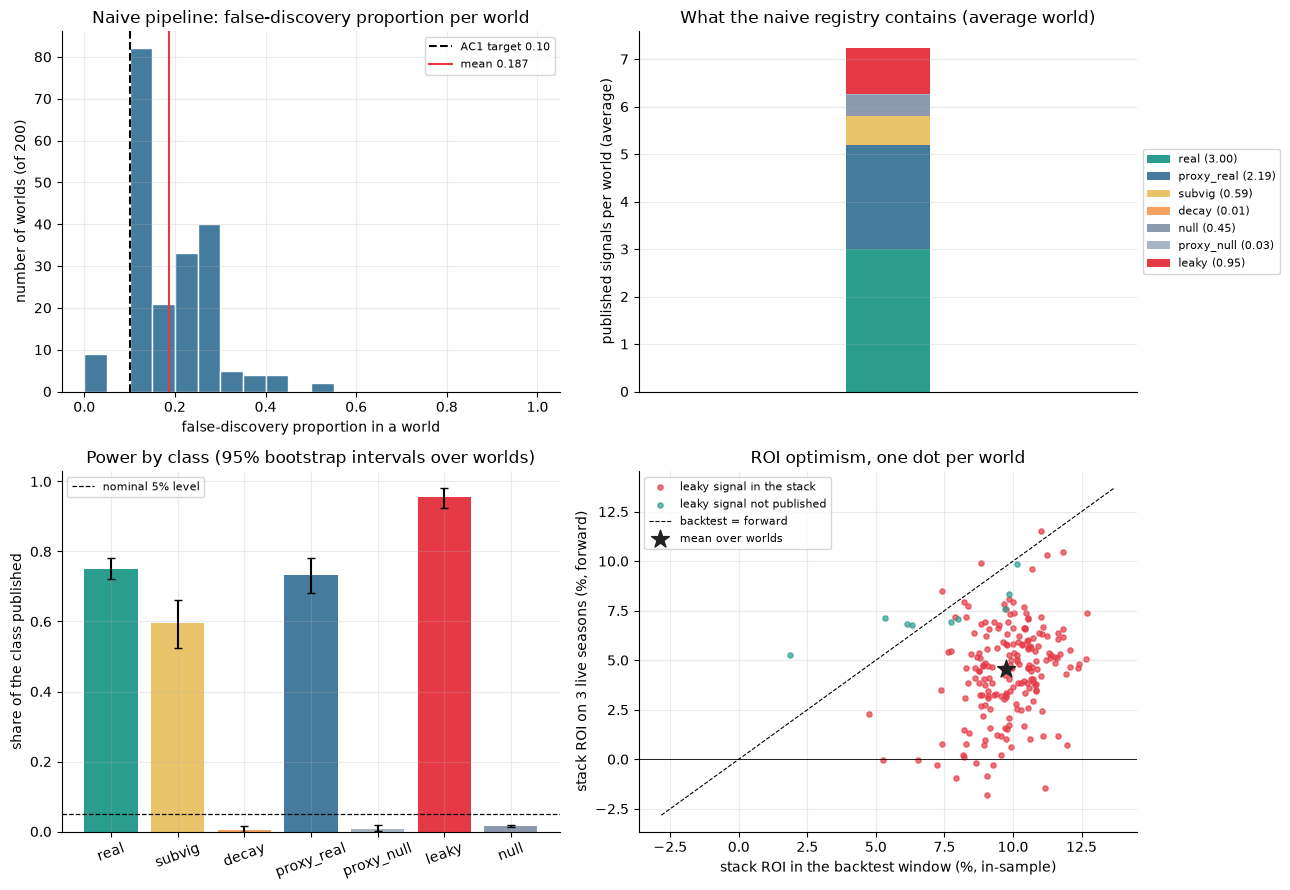

In [18]:
# Visualization only: uses fdp, sel, cls, A, leaky_pub computed above.
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) FDP histogram
ax[0, 0].hist(fdp, bins=np.linspace(0, 1, 21), color=PALETTE["proxy_real"], edgecolor="white")
ax[0, 0].axvline(0.10, color="k", ls="--", label="AC1 target 0.10")
ax[0, 0].axvline(fdp.mean(), color=PALETTE["leaky"], label=f"mean {fdp.mean():.3f}")
ax[0, 0].set_xlabel("false-discovery proportion in a world"); ax[0, 0].set_ylabel("number of worlds (of 200)")
ax[0, 0].set_title("Naive pipeline: false-discovery proportion per world"); ax[0, 0].legend(fontsize=8)
# (b) published per class, stacked
bottom = np.zeros(1)
for c in ["real", "proxy_real", "subvig", "decay", "null", "proxy_null", "leaky"]:
    v = sel[:, cls == c].sum(axis=1).mean()
    ax[0, 1].bar(0, v, bottom=bottom[0], color=PALETTE[c], label=f"{c} ({v:.2f})", width=0.5)
    bottom[0] += v
ax[0, 1].set_xticks([]); ax[0, 1].set_ylabel("published signals per world (average)")
ax[0, 1].set_title("What the naive registry contains (average world)"); ax[0, 1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax[0, 1].set_xlim(-1.5, 1.5)
# (c) power by class
pw = [(c, *boot_ci(sel[:, cls == c].mean(axis=1))) for c in CLASS_ORDER]
xs = np.arange(len(pw))
ax[1, 0].bar(xs, [p[1] for p in pw], color=[PALETTE[p[0]] for p in pw], yerr=[[p[1] - p[2] for p in pw], [p[3] - p[1] for p in pw]], capsize=3)
ax[1, 0].axhline(0.05, color="k", ls="--", lw=0.9, label="nominal 5% level")
ax[1, 0].set_xticks(xs); ax[1, 0].set_xticklabels([p[0] for p in pw], rotation=20)
ax[1, 0].set_ylabel("share of the class published"); ax[1, 0].set_title("Power by class (95% bootstrap intervals over worlds)")
ax[1, 0].legend(fontsize=8)
# (d) ROI in-sample vs forward
lk = leaky_pub.astype(bool)
ax[1, 1].scatter(100 * A["roi_in_eval"][lk], 100 * A["roi_in_fwd"][lk], s=14, color=PALETTE["in_sample"], alpha=0.7, label="leaky signal in the stack")
if (~lk).any():
    ax[1, 1].scatter(100 * A["roi_in_eval"][~lk], 100 * A["roi_in_fwd"][~lk], s=14, color=PALETTE["forward"], alpha=0.7, label="leaky signal not published")
lim = [min(100 * A["roi_in_eval"].min(), 100 * A["roi_in_fwd"].min()) - 1, max(100 * A["roi_in_eval"].max(), 100 * A["roi_in_fwd"].max()) + 1]
ax[1, 1].plot(lim, lim, color="k", lw=0.8, ls="--", label="backtest = forward")
ax[1, 1].axhline(0, color="k", lw=0.6)
ax[1, 1].scatter([100 * A["roi_in_eval"].mean()], [100 * A["roi_in_fwd"].mean()], marker="*", s=180, color=PALETTE["market"], label="mean over worlds", zorder=5)
ax[1, 1].set_xlabel("stack ROI in the backtest window (%, in-sample)"); ax[1, 1].set_ylabel("stack ROI on 3 live seasons (%, forward)")
ax[1, 1].set_title("ROI optimism, one dot per world"); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**How to read this chart**

The x-axis is the evaluation season (4 to 12); the y-axis is the **exact** expected Brier gap over the market of the frozen forecaster, in units of $10^{-4}$, averaged over the 200 worlds with 95% bootstrap bands. The **decay** forecaster (orange) is a real edge in season 4 only: its gap is clearly positive there and then turns **negative and stays there**. Once the true effect is zero, a frozen slope that is still applied is just noise added to the market price, so the gap is below zero rather than flat at zero. That is the situation the edge-decay monitor (deliverable D4, criterion AC4) has to catch: the backtest average over seasons 4-12 is negative, but a client who watched only the first evaluation season would have published it. The **sub-vig** forecaster (yellow) keeps a steady positive gap in every season: it is a genuine, stable edge that is simply too small to beat the overround when followed.

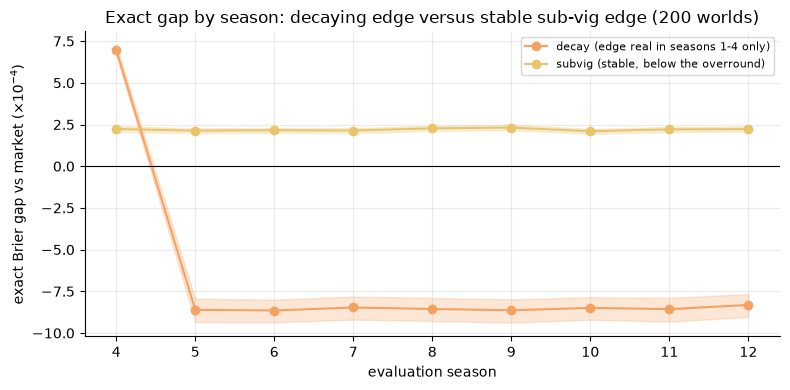

In [19]:
# Visualization only: uses dec_ci and sub_ci computed above.
seas = np.arange(4, 4 + len(dec_ci))
fig, ax = plt.subplots(figsize=(8, 4))
for lab, ci, col in (("decay (edge real in seasons 1-4 only)", dec_ci, PALETTE["decay"]), ("subvig (stable, below the overround)", sub_ci, PALETTE["subvig"])):
    m = np.array([c[0] for c in ci]); lo = np.array([c[1] for c in ci]); hi = np.array([c[2] for c in ci])
    ax.plot(seas, 1e4 * m, "o-", color=col, label=lab)
    ax.fill_between(seas, 1e4 * lo, 1e4 * hi, color=col, alpha=0.25)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("evaluation season"); ax.set_ylabel(r"exact Brier gap vs market ($\times10^{-4}$)")
ax.set_title("Exact gap by season: decaying edge versus stable sub-vig edge (200 worlds)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Limitations and what these results do not say

* **The simulator is the world.** Every number above is a property of the planted structure: 40 signals with a fixed class layout, effect sizes tuned so that the naive screen finds some but not all real edges, a proportional overround, a single planted mispricing. Power by class is a consequence of those tuning choices, not a finding about real markets. The false-positive rate of the nulls is if anything *low* (a frozen-slope forecaster on a null feature is slightly worse than the market, so a one-sided test rarely fires); a backtest that refits on the window it tests would show more.
* **Money is outside the sources.** The three papers evaluate forecasts with proper scoring rules. They do not model profit or return, bookmaker margin and de-margining beyond the rescaling used in one demonstration, staking rules such as Kelly, transaction costs, commissions or bet limits, the favourite-longshot bias, or outcomes with three results (a draw). None of them states that a better Brier score than the bookmaker implies a positive expected return. All ROI figures here (flat unit stakes, threshold and follow rules, a 4.5% proportional overround, no limits or slippage) are *derived here*. The planted longshot mispricing is a modelling choice, not evidence about real markets. Choe and Ramdas also note that sportsbook odds are set to maximise the book's profit, not purely accuracy.
* **Descriptive, not predictive.** The confidence-sequence results Notebook 3 uses describe performance achieved so far; the authors state that past outperformance cannot be extrapolated to the future without unverifiable assumptions. A signal that passes in the backtest and in three live seasons of a simulator can still decay, which is exactly why D4 exists.
* **Binary outcome only.** The paper's own sports data are binary (home win); a three-way sport would need a different score and a different money rule.
* **Simulator conveniences.** Features are decorrelated within families, the leak is a clean additive contamination, referee tendencies are fixed per referee, teams do not respond to the market. Real signal libraries are collinear, leaks are subtler, and edges are priced away.

## 8. Recap

**What exists now.** A finished build for the first half of the engagement: a project brief with four acceptance criteria, a data contract, a simulator that stands in for the feeds (with a fixed, known truth table: 4 real edges, 1 sub-vig edge, 1 decaying edge, two proxy clusters, 1 look-ahead leak, 27 nulls, and a planted longshot mispricing), 40 frozen and predictable single-signal forecasters, the client's naive pipeline (screen at $p<0.05$, stack, flat-stake ROI in-sample and forward) and its audit over 200 worlds. The audit gives the numbers Notebook 3 must beat: the naive registry fails AC1 (mean false-discovery proportion about 19% against a 10% target) and AC2 (the look-ahead signal is published in essentially every world), and its stack's backtest ROI is about twice its forward ROI. The four design targets of the simulator were checked against the audit above, with any miss reported in place.

**Exported cells** (each starts with `# EXPORT: <name>`, definitions only, so Notebook 3 can run them by marker):

| Export | Provides |
|---|---|
| `edgelab_config` | `CFG` |
| `edgelab_sim` | `simulate_world(seed, cfg=CFG)` |
| `edgelab_devig` | `devig(odds_home, odds_away)` |
| `edgelab_fit` | `fit_forecasters(W, cfg=CFG)` |
| `edgelab_scores` | `brier(p, y)`, `score_diff(p, q, y)` |
| `edgelab_truth` | `true_gap(W, F, by_season=False)`, `is_edge(W, F)` |
| `edgelab_money` | `roi_flat(...)`, `expected_roi_flat(...)` |
| `edgelab_naive` | `naive_screen(W, F, alpha=0.05)`, `stack_fit`, `stack_predict` |

**What Notebook 3 does with it.** It applies the three papers to this pipeline and scores the acceptance criteria against the baseline above. *Prove*: anytime-valid confidence sequences and e-processes for each forecaster's mean Brier differential against the de-margined market (Choe and Ramdas), which are valid under continuous monitoring but require predictable forecasts, so the leaky signal should be excluded before it is scored. *Screen*: e-LOND online false-discovery-rate control with e-values (Xu and Ramdas), valid under arbitrary dependence, hence under signals that reuse the same games. *Combine*: calibeating and multi-calibeating (Chen, Huang, Jordan and Luo), which post-process the forecasts (Notebook 3 tests whether they can pick up the planted price-band mispricing). *Monitor*: an alarm on the decaying signal, scored against AC4. The acceptance criteria AC1-AC4 are then re-scored on the same 200 worlds, next to the naive baseline.